# Análisis de la desaprobación escolar mediante aprendizaje automático
### Datos de Matriculación y Trayectoria Estudiantil 2021–2024

Este proyecto utiliza registros educativos agregados para analizar la desaprobación escolar. La revisión inicial comprende los años 2021–2024 y el análisis principal se desarrolla con los periodos 2023 y 2024.

**Fuente de datos:** Ministerio de Educación del Perú (MINEDU) — Sistema de Información de Apoyo a la Gestión de la Institución Educativa (SIAGIE). [Matriculación y Trayectoria Estudiantil 2021–2024 — Plataforma Nacional de Datos Abiertos](https://www.datosabiertos.gob.pe/dataset/matriculaci%C3%B3n-y-trayectoria-estudiantil-2021-2024).


# 1. Carga de datos


In [1]:
from pathlib import Path
import csv
import pandas as pd

nombres_archivos = {
    anio: f"Matriculación y Trayectoria Estudiantil {anio}.csv"
    for anio in range(2021, 2025)
}

rutas_posibles = [Path("/content"), Path.cwd(), Path.cwd() / "Parcial"]
carpeta_datos = next(
    (
        ruta for ruta in rutas_posibles
        if all((ruta / nombre).is_file() for nombre in nombres_archivos.values())
    ),
    None,
)
if carpeta_datos is None:
    raise FileNotFoundError(
        "No se encontraron los cuatro CSV en /content, la carpeta actual o ./Parcial."
    )


def detectar_formato_csv(ruta):
    muestra_binaria = ruta.read_bytes()[:200_000]
    for codificacion in ("utf-8-sig", "utf-8", "cp1252", "latin-1"):
        try:
            muestra = muestra_binaria.decode(codificacion)
            break
        except UnicodeDecodeError:
            continue
    else:
        raise RuntimeError(f"No se pudo detectar la codificación de {ruta.name}")

    try:
        separador = csv.Sniffer().sniff(muestra, delimiters=",;\t|").delimiter
    except csv.Error:
        separadores = (",", ";", "\t", "|")
        separador = max(separadores, key=muestra.count)
    return codificacion, separador


dataframes = {}
for anio, nombre in nombres_archivos.items():
    ruta = carpeta_datos / nombre
    codificacion, separador = detectar_formato_csv(ruta)
    dataframes[anio] = pd.read_csv(
        ruta,
        sep=separador,
        encoding=codificacion,
        low_memory=False,
    )

df_2021 = dataframes[2021]
df_2022 = dataframes[2022]
df_2023 = dataframes[2023]
df_2024 = dataframes[2024]

resumen_archivos = pd.DataFrame(
    [
        {"Año": anio, "Filas": len(df), "Columnas": df.shape[1]}
        for anio, df in dataframes.items()
    ]
)
display(resumen_archivos)

columnas_por_anio = pd.DataFrame(
    {
        "Año": list(dataframes),
        "Nombres de columnas": [", ".join(df.columns) for df in dataframes.values()],
    }
)
display(columnas_por_anio)

columnas_union = sorted(set().union(*(set(df.columns) for df in dataframes.values())))
columnas_comunes = set.intersection(*(set(df.columns) for df in dataframes.values()))
columnas_con_diferencias = [
    columna for columna in columnas_union if columna not in columnas_comunes
]
diferencias_estructurales = pd.DataFrame(
    [
        {
            "Variable": columna,
            **{
                str(anio): "Sí" if columna in dataframes[anio].columns else "No"
                for anio in dataframes
            },
        }
        for columna in columnas_con_diferencias
    ]
)
display(diferencias_estructurales)


,Año,Filas,Columnas
0,2021,566359,26
1,2022,558785,26
2,2023,544834,26
3,2024,535137,26


,Año,Nombres de columnas
0,2021,"cod_mod, anexo, Nombre, gestion, id_nivel, dsc..."
1,2022,"cod_mod, anexo, Nombre, gestion, id_nivel, dsc..."
2,2023,"cod_mod, anexo, Nombre, gestion, id_nivel, dsc..."
3,2024,"cod_mod, anexo, Nombre, gestion, id_nivel, dsc..."


,Variable,2021,2022,2023,2024
0,Desaprobado,No,No,Sí,Sí
1,PromocionGuiada,Sí,Sí,No,No


Los cuatro archivos contienen 26 columnas y entre 535,137 y 566,359 registros. La diferencia estructural relevante es que 2021–2022 incluyen `PromocionGuiada`, mientras 2023–2024 incluyen `Desaprobado`.

# 2. Selección de 2023 y 2024


In [2]:
# DataFrames que se utilizarán en las siguientes etapas
df_2023 = dataframes[2023]
df_2024 = dataframes[2024]

mismas_columnas = df_2023.columns.equals(df_2024.columns)
tipos_2023 = df_2023.dtypes.astype(str)
tipos_2024 = df_2024.dtypes.astype(str)
mismos_tipos = tipos_2023.equals(tipos_2024)

compatibilidad_2023_2024 = pd.DataFrame(
    {
        "Comprobación": [
            "Dimensiones de 2023",
            "Dimensiones de 2024",
            "Mismas columnas",
            "Mismos tipos de datos",
            "Registros conjuntos",
        ],
        "Resultado": [
            f"{df_2023.shape[0]:,} filas × {df_2023.shape[1]} columnas",
            f"{df_2024.shape[0]:,} filas × {df_2024.shape[1]} columnas",
            "Sí" if mismas_columnas else "No",
            "Sí" if mismos_tipos else "No",
            f"{len(df_2023) + len(df_2024):,}",
        ],
    }
)
display(compatibilidad_2023_2024)

diferencias_tipos = pd.DataFrame(
    [
        {
            "Variable": columna,
            "Tipo 2023": tipos_2023[columna],
            "Tipo 2024": tipos_2024[columna],
            "Nulos 2023": int(df_2023[columna].isna().sum()),
            "Nulos 2024": int(df_2024[columna].isna().sum()),
        }
        for columna in df_2023.columns
        if tipos_2023[columna] != tipos_2024[columna]
    ]
)
display(diferencias_tipos)


,Comprobación,Resultado
0,Dimensiones de 2023,"544,834 filas × 26 columnas"
1,Dimensiones de 2024,"535,137 filas × 26 columnas"
2,Mismas columnas,Sí
3,Mismos tipos de datos,No
4,Registros conjuntos,"1,079,971"


,Variable,Tipo 2023,Tipo 2024,Nulos 2023,Nulos 2024
0,Edad,int64,float64,0,1


### Selección del periodo de estudio

Después de revisar los cuatro periodos, se seleccionaron 2023 y 2024 por ser los años más recientes y compartir las mismas 26 columnas, incluida `Desaprobado`; 2021–2022 presentan `PromocionGuiada` en su lugar. La única diferencia de tipo entre los años seleccionados corresponde a `Edad` (`int64` en 2023 y `float64` en 2024 por un valor faltante), aspecto que se revisará posteriormente durante la limpieza. En conjunto, `df_2023` y `df_2024` conservan 1,079,971 registros para el análisis.


### Creación de `df_total`


In [3]:
df_2023["ANIO"] = 2023
df_2024["ANIO"] = 2024

df_total = pd.concat([df_2023, df_2024], ignore_index=True)

dimensiones = pd.DataFrame(
    [
        {"DataFrame": "df_2023", "Filas": df_2023.shape[0], "Columnas": df_2023.shape[1]},
        {"DataFrame": "df_2024", "Filas": df_2024.shape[0], "Columnas": df_2024.shape[1]},
        {"DataFrame": "df_total", "Filas": df_total.shape[0], "Columnas": df_total.shape[1]},
    ]
)
display(dimensiones)

registros_por_anio = (
    df_total["ANIO"]
    .value_counts()
    .sort_index()
    .rename_axis("ANIO")
    .reset_index(name="Registros")
)
display(registros_por_anio)

suma_filas_coincide = len(df_2023) + len(df_2024) == len(df_total)
print(
    f"Verificación de filas: {len(df_2023):,} + {len(df_2024):,} "
    f"= {len(df_total):,} -> {suma_filas_coincide}"
)


,DataFrame,Filas,Columnas
0,df_2023,544834,27
1,df_2024,535137,27
2,df_total,1079971,27


,ANIO,Registros
0,2023,544834
1,2024,535137


Verificación de filas: 544,834 + 535,137 = 1,079,971 -> True


`df_total` se utilizará para las etapas de limpieza y análisis exploratorio. `df_2023` y `df_2024` se conservarán separados para el posterior modelado y la evaluación temporal.


# 3. Limpieza de datos

Se revisan valores faltantes, duplicados, tipos de datos y posibles inconsistencias antes del análisis.

In [4]:
import numpy as np
import pandas as pd

# Se crea una copia para no modificar el DataFrame combinado original.
df_limpio = df_total.copy()

nulos = (
    df_limpio.isna().sum()
    .rename("Valores nulos")
    .to_frame()
    .query("`Valores nulos` > 0")
)
tipos = df_limpio.dtypes.astype(str).rename("Tipo de dato").to_frame()
duplicados_antes = int(df_limpio.duplicated().sum())

display(nulos)
display(tipos)
print(f"Filas duplicadas exactas: {duplicados_antes:,}")

,Valores nulos
Edad,1
TipoDiscaIntegrada,954466


,Tipo de dato
cod_mod,int64
anexo,int64
Nombre,str
gestion,str
id_nivel,str
dsc_nivel,str
Edad,float64
TipoDiscaIntegrada,str
TotalEstudiantes,int64
Discapacidad,int64


Filas duplicadas exactas: 0


Solo `Edad` presenta un valor faltante, mientras que `TipoDiscaIntegrada` tiene 954,466 nulos. No se imputan en esta etapa: `Edad` se tratará dentro del preprocesamiento y la segunda variable se excluirá del modelado por su baja disponibilidad.

In [5]:
filas_antes = len(df_limpio)

# Se eliminan espacios sobrantes solo si realmente existen.
columnas_texto = df_limpio.select_dtypes(include=["object", "string"]).columns
espacios_detectados = {}
for columna in columnas_texto:
    serie = df_limpio[columna].dropna().astype(str)
    cantidad = int(serie.ne(serie.str.strip()).sum())
    espacios_detectados[columna] = cantidad
    if cantidad > 0:
        df_limpio[columna] = df_limpio[columna].str.strip()

# Se eliminan solamente filas completamente idénticas.
df_limpio = df_limpio.drop_duplicates().reset_index(drop=True)
duplicados_eliminados = filas_antes - len(df_limpio)

# Comprobaciones sencillas de valores numéricos imposibles.
columnas_conteo = [
    "TotalEstudiantes", "Discapacidad", "Mujer", "Hombre", "Venezolanos",
    "Peruanos", "Extranjeros", "DNI_validado", "DNI_SinValidar", "No_DNI",
    "Aprobado", "Desaprobado", "Retirado", "Fallecido",
    "RequiereRecuperacion", "Matriculado", "PostergaEvaluacion", "tot_atraso"
]
valores_negativos = int((df_limpio[columnas_conteo] < 0).sum().sum())
edades_imposibles = int(((df_limpio["Edad"] < 0) | (df_limpio["Edad"] > 100)).sum())

resumen_limpieza = pd.DataFrame({
    "Indicador": [
        "Filas antes", "Filas después", "Duplicados eliminados",
        "Nulos restantes", "Número de columnas"
    ],
    "Resultado": [
        filas_antes, len(df_limpio), duplicados_eliminados,
        int(df_limpio.isna().sum().sum()), df_limpio.shape[1]
    ]
})

display(resumen_limpieza)
print(f"Espacios sobrantes encontrados: {sum(espacios_detectados.values()):,}")
print(f"Conteos negativos: {valores_negativos}")
print(f"Edades fuera del rango 0 a 100: {edades_imposibles}")

,Indicador,Resultado
0,Filas antes,1079971
1,Filas después,1079971
2,Duplicados eliminados,0
3,Nulos restantes,954467
4,Número de columnas,27


Espacios sobrantes encontrados: 0
Conteos negativos: 0
Edades fuera del rango 0 a 100: 0


No se encontraron duplicados exactos, espacios sobrantes ni valores numéricos imposibles. Se conservaron las 1,079,971 filas y las 27 columnas, sin eliminar valores altos que pueden ser observaciones válidas.

# 4. Análisis exploratorio y gráficos

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# La muestra se usa solo para agilizar algunos gráficos.
muestra_graficos = df_limpio.sample(
    n=min(200_000, len(df_limpio)),
    random_state=42
)

### Gráfico 1 — Registros por año

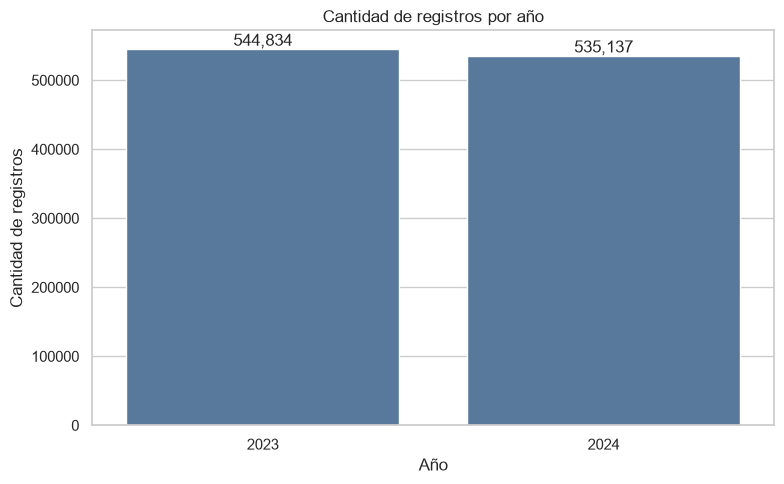

In [7]:
registros_anio = df_limpio["ANIO"].value_counts().sort_index()

ax = sns.barplot(
    x=registros_anio.index.astype(str),
    y=registros_anio.values,
    color="#4C78A8"
)
ax.set_title("Cantidad de registros por año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de registros")
ax.bar_label(ax.containers[0], fmt="{:,.0f}")
plt.tight_layout()
plt.show()

El año 2023 contiene 544,834 registros y 2024 contiene 535,137. Los dos periodos tienen volúmenes cercanos, con una diferencia aproximada de 9,700 filas.

### Gráfico 2 — Total de estudiantes

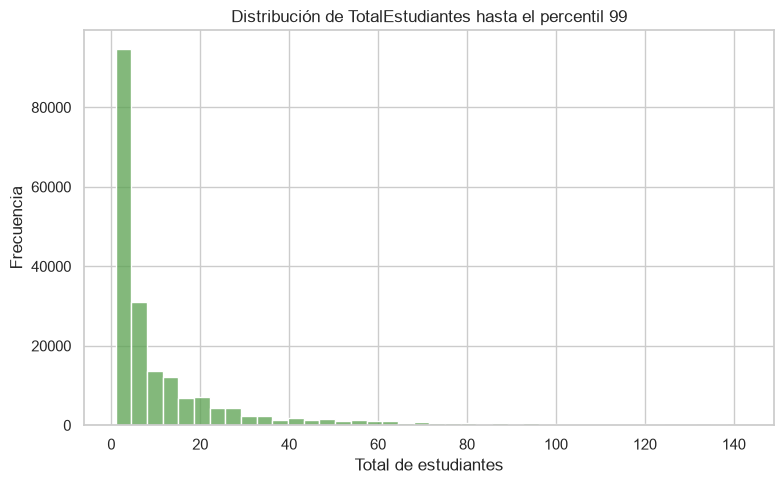

Mediana: 5
Percentil 99: 142
Máximo observado: 767


In [8]:
limite_total = df_limpio["TotalEstudiantes"].quantile(0.99)
datos_total = muestra_graficos[
    muestra_graficos["TotalEstudiantes"] <= limite_total
]

sns.histplot(datos_total["TotalEstudiantes"], bins=40, color="#59A14F")
plt.title("Distribución de TotalEstudiantes hasta el percentil 99")
plt.xlabel("Total de estudiantes")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print(f"Mediana: {df_limpio['TotalEstudiantes'].median():.0f}")
print(f"Percentil 99: {limite_total:.0f}")
print(f"Máximo observado: {df_limpio['TotalEstudiantes'].max():.0f}")

La mayor parte de los registros concentra pocos estudiantes: la mediana es 5 y el percentil 99 llega a 142. La distribución presenta asimetría hacia la derecha y algunos grupos alcanzan hasta 767 estudiantes; esos valores solo se limitaron en el gráfico.

### Gráfico 3 — Atraso escolar

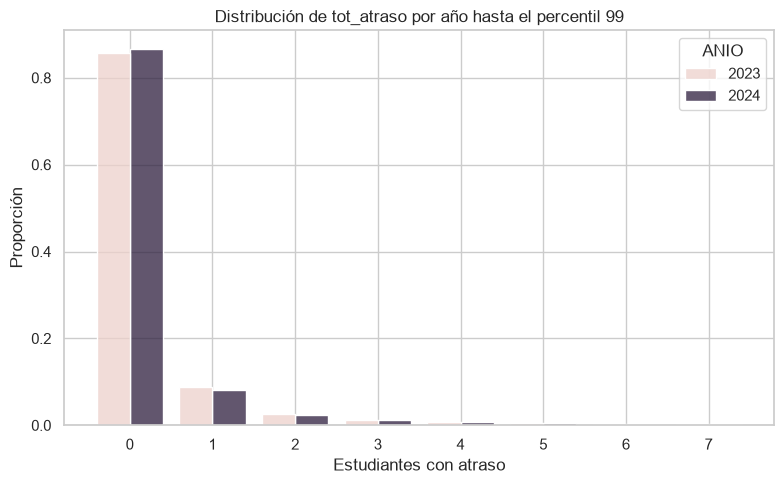

Registros con tot_atraso igual a cero: 921,620
Percentil 99: 7
Máximo observado: 117


In [9]:
limite_atraso = int(df_limpio["tot_atraso"].quantile(0.99))
datos_atraso = muestra_graficos[
    muestra_graficos["tot_atraso"] <= limite_atraso
]

sns.histplot(
    data=datos_atraso,
    x="tot_atraso",
    hue="ANIO",
    discrete=True,
    stat="probability",
    common_norm=False,
    multiple="dodge",
    shrink=0.8
)
plt.title("Distribución de tot_atraso por año hasta el percentil 99")
plt.xlabel("Estudiantes con atraso")
plt.ylabel("Proporción")
plt.tight_layout()
plt.show()

print(f"Registros con tot_atraso igual a cero: {(df_limpio['tot_atraso'] == 0).sum():,}")
print(f"Percentil 99: {limite_atraso}")
print(f"Máximo observado: {df_limpio['tot_atraso'].max()}")

El atraso es cero en 921,620 registros, por lo que la distribución está muy concentrada en ese valor en ambos años. Fuera de esa concentración existe una cola hacia la derecha: el percentil 99 es 7 y el máximo llega a 117.

### Gráfico 4 — Tasa de atraso

,Comprobación,Casos
0,tot_atraso mayor que TotalEstudiantes,0
1,TotalEstudiantes menor o igual a cero,0


Tasas superiores a 100 %: 0


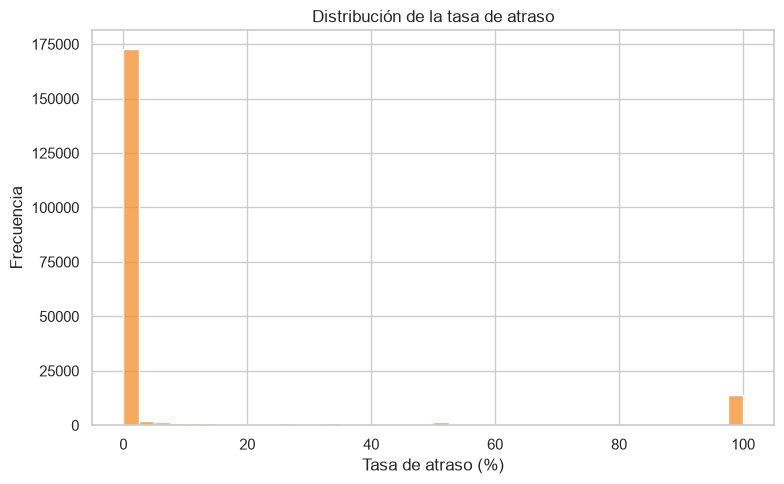

In [10]:
verificacion_tasa = pd.DataFrame({
    "Comprobación": [
        "tot_atraso mayor que TotalEstudiantes",
        "TotalEstudiantes menor o igual a cero"
    ],
    "Casos": [
        int((df_limpio["tot_atraso"] > df_limpio["TotalEstudiantes"]).sum()),
        int((df_limpio["TotalEstudiantes"] <= 0).sum())
    ]
})
display(verificacion_tasa)

df_limpio["TASA_ATRASO"] = np.where(
    df_limpio["TotalEstudiantes"] > 0,
    (df_limpio["tot_atraso"] / df_limpio["TotalEstudiantes"]) * 100,
    np.nan
)

tasas_imposibles = int((df_limpio["TASA_ATRASO"] > 100).sum())
print(f"Tasas superiores a 100 %: {tasas_imposibles}")

sns.histplot(
    df_limpio.sample(n=min(200_000, len(df_limpio)), random_state=42)["TASA_ATRASO"],
    bins=40,
    color="#F28E2B"
)
plt.title("Distribución de la tasa de atraso")
plt.xlabel("Tasa de atraso (%)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

La tasa se pudo calcular para todos los registros y no se encontraron valores superiores a 100 %. La distribución conserva una gran concentración en 0 %, mientras que la media general es 8.36 % debido a los valores positivos de la cola.

### Gráfico 5 — Tasa de atraso por año

,Media,Mediana
ANIO,,
2023,8.796736,0.0
2024,7.908558,0.0


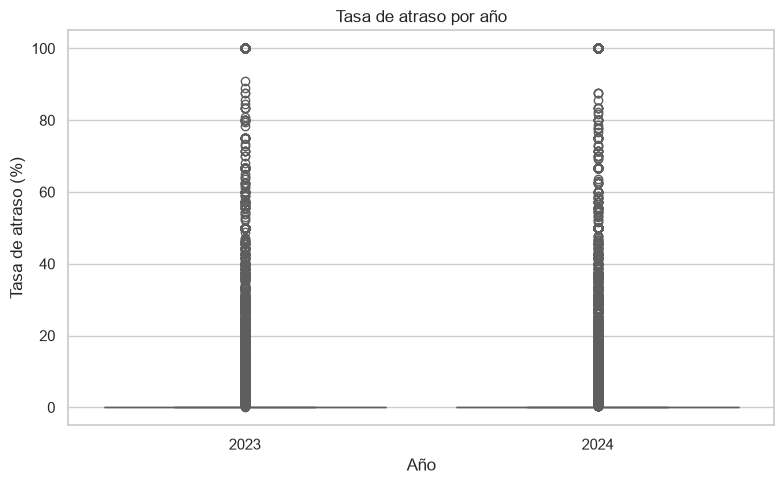

In [11]:
resumen_tasa_anio = (
    df_limpio.groupby("ANIO")["TASA_ATRASO"]
    .agg(["mean", "median"])
    .rename(columns={"mean": "Media", "median": "Mediana"})
)
display(resumen_tasa_anio)

sns.boxplot(
    data=df_limpio.sample(n=min(100_000, len(df_limpio)), random_state=42),
    x="ANIO",
    y="TASA_ATRASO",
    color="#E15759"
)
plt.title("Tasa de atraso por año")
plt.xlabel("Año")
plt.ylabel("Tasa de atraso (%)")
plt.tight_layout()
plt.show()

La mediana es 0 % en ambos años por la alta cantidad de registros sin atraso. La media disminuye de 8.80 % en 2023 a 7.91 % en 2024, aunque ambos periodos mantienen valores elevados en la parte superior de la distribución.

### Gráfico 6 — Tasa de atraso por nivel educativo

,dsc_nivel,TASA_ATRASO
0,Secundaria,17.766345
1,Primaria,8.667483
2,Inicial - Cuna-Jardín,0.000000
3,Inicial - Cuna,0.000000
4,Inicial no escolarizado,0.000000
5,Inicial - Jardín,0.000000


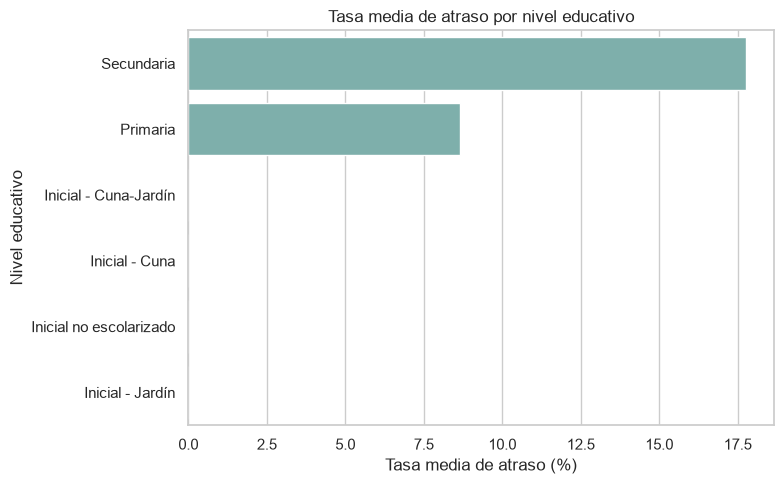

In [12]:
tasa_por_nivel = (
    df_limpio.groupby("dsc_nivel", observed=True)["TASA_ATRASO"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
display(tasa_por_nivel)

sns.barplot(data=tasa_por_nivel, x="TASA_ATRASO", y="dsc_nivel", color="#76B7B2")
plt.title("Tasa media de atraso por nivel educativo")
plt.xlabel("Tasa media de atraso (%)")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

Secundaria presenta la tasa media más alta, con 17.77 %, seguida de Primaria con 8.67 %. Las categorías de nivel Inicial registran una tasa media de 0 % en estos datos.

### Gráfico 7 — Tasa de atraso por tipo de gestión

,gestion,TASA_ATRASO
0,Pública de gestión directa,9.594326
1,Pública de gestión privada,9.215733
2,Privada,4.047282


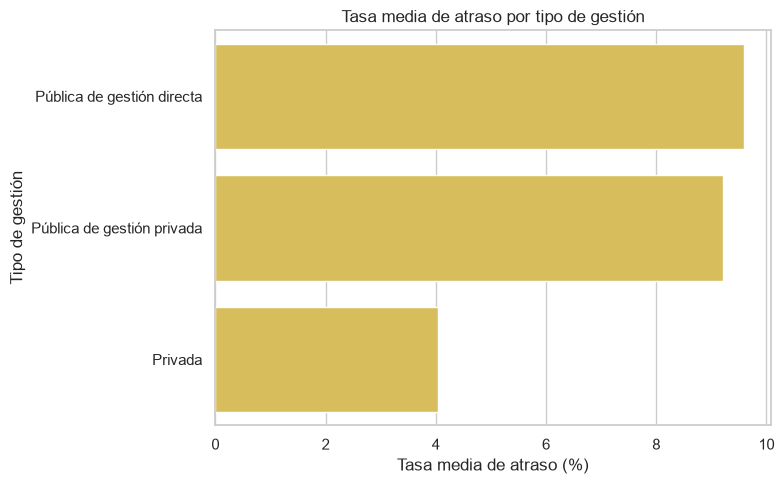

In [13]:
tasa_por_gestion = (
    df_limpio.groupby("gestion", observed=True)["TASA_ATRASO"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
display(tasa_por_gestion)

sns.barplot(data=tasa_por_gestion, x="TASA_ATRASO", y="gestion", color="#EDC948")
plt.title("Tasa media de atraso por tipo de gestión")
plt.xlabel("Tasa media de atraso (%)")
plt.ylabel("Tipo de gestión")
plt.tight_layout()
plt.show()

La gestión pública directa registra la media más alta, con 9.59 %, seguida de la gestión pública privada con 9.22 %. En la gestión privada la media es menor, con 4.05 %.

### Gráfico 8 — Correlación de variables numéricas

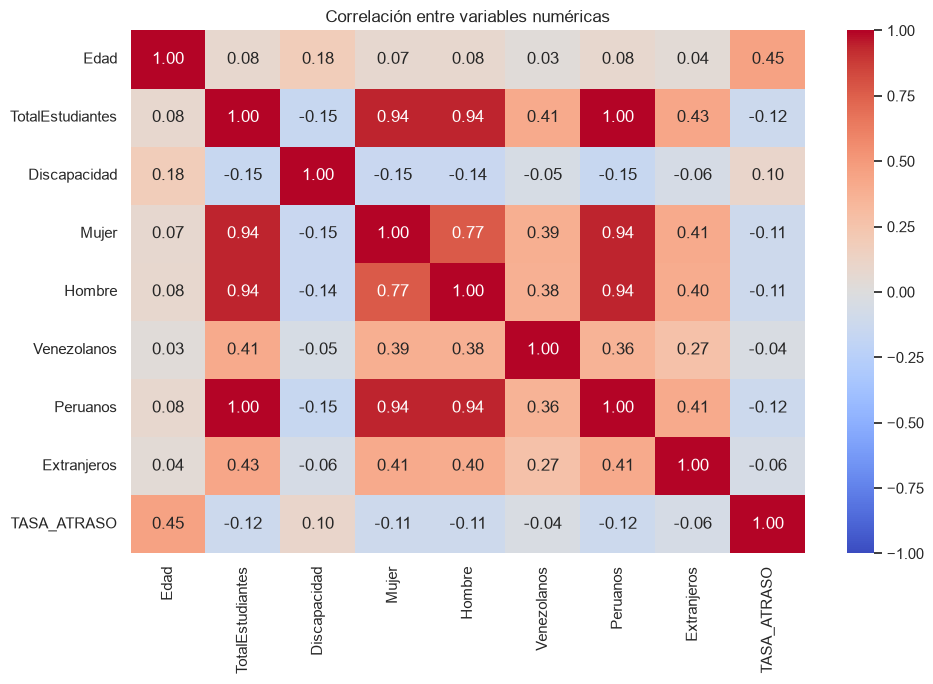

In [14]:
variables_correlacion = [
    "Edad", "TotalEstudiantes", "Discapacidad", "Mujer", "Hombre",
    "Venezolanos", "Peruanos", "Extranjeros", "TASA_ATRASO"
]
matriz_correlacion = df_limpio[variables_correlacion].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Correlación entre variables numéricas")
plt.tight_layout()
plt.show()

`Edad` presenta la relación lineal más alta con `TASA_ATRASO` (0.45), mientras que las relaciones con los conteos restantes son más bajas. `TotalEstudiantes`, `Mujer`, `Hombre` y `Peruanos` están muy correlacionados entre sí porque describen el tamaño y la composición del mismo grupo; esto no implica causalidad.

# 5. Selección de variables

Se trabajará con una tarea de regresión para estimar `TASA_ATRASO` y una tarea de clasificación para identificar la presencia de atraso.

In [15]:
df_limpio["HAY_ATRASO"] = (df_limpio["tot_atraso"] > 0).astype(int)

distribucion_clases = (
    df_limpio["HAY_ATRASO"]
    .value_counts()
    .sort_index()
    .rename_axis("HAY_ATRASO")
    .reset_index(name="Cantidad")
)
distribucion_clases["Porcentaje"] = (
    distribucion_clases["Cantidad"] / len(df_limpio) * 100
).round(2)
display(distribucion_clases)

,HAY_ATRASO,Cantidad,Porcentaje
0,0,921620,85.34
1,1,158351,14.66


La clase 0 representa aproximadamente 85.34 % de los registros y la clase 1 representa 14.66 %. Esta diferencia se tendrá en cuenta al interpretar especialmente Recall, F1 y ROC-AUC.

In [16]:
variables_predictoras = [
    "Edad", "TotalEstudiantes", "Discapacidad", "Venezolanos",
    "Extranjeros", "gestion", "dsc_nivel"
]

motivos_no_usar = {
    "cod_mod": "Identificador de la institución",
    "anexo": "Parte del identificador institucional",
    "Nombre": "Nombre de la institución",
    "id_nivel": "Duplica la información de dsc_nivel",
    "TipoDiscaIntegrada": "Presenta demasiados valores nulos",
    "Mujer": "Muy relacionada con el tamaño total del grupo",
    "Hombre": "Muy relacionada con el tamaño total del grupo",
    "Peruanos": "Casi reproduce TotalEstudiantes",
    "DNI_validado": "Variable administrativa",
    "DNI_SinValidar": "Variable administrativa",
    "No_DNI": "Variable administrativa",
    "Aprobado": "Resultado académico del mismo periodo",
    "Desaprobado": "Resultado académico del mismo periodo",
    "Retirado": "Resultado académico del mismo periodo",
    "Fallecido": "Resultado del mismo periodo",
    "RequiereRecuperacion": "Resultado académico del mismo periodo",
    "Matriculado": "Resultado académico del mismo periodo",
    "PostergaEvaluacion": "Resultado académico del mismo periodo",
    "tot_atraso": "Permite construir directamente los objetivos",
    "ANIO": "Se usa para separar los periodos",
    "TASA_ATRASO": "Es el objetivo de regresión",
    "HAY_ATRASO": "Es el objetivo de clasificación"
}

seleccion_variables = pd.DataFrame({"Variable": df_limpio.columns})
seleccion_variables["Usar / No usar"] = seleccion_variables["Variable"].apply(
    lambda x: "Usar" if x in variables_predictoras else "No usar"
)
seleccion_variables["Motivo"] = seleccion_variables["Variable"].apply(
    lambda x: "Característica educativa o contextual" if x in variables_predictoras
    else motivos_no_usar.get(x, "No necesaria para estas tareas")
)
display(seleccion_variables)

,Variable,Usar / No usar,Motivo
0,cod_mod,No usar,Identificador de la institución
1,anexo,No usar,Parte del identificador institucional
2,Nombre,No usar,Nombre de la institución
3,gestion,Usar,Característica educativa o contextual
4,id_nivel,No usar,Duplica la información de dsc_nivel
5,dsc_nivel,Usar,Característica educativa o contextual
6,Edad,Usar,Característica educativa o contextual
7,TipoDiscaIntegrada,No usar,Presenta demasiados valores nulos
8,TotalEstudiantes,Usar,Característica educativa o contextual
9,Discapacidad,Usar,Característica educativa o contextual


Se seleccionaron siete variables educativas y contextuales. Se excluyeron identificadores, variables administrativas, resultados del mismo periodo, columnas muy incompletas y variables que permiten construir directamente los objetivos.

# 6. Preparación de datos

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Los periodos se mantienen separados para la evaluación temporal.
df_modelo_2023 = df_limpio[df_limpio["ANIO"] == 2023].copy()
df_modelo_2024 = df_limpio[df_limpio["ANIO"] == 2024].copy()

variables_numericas = [
    "Edad", "TotalEstudiantes", "Discapacidad", "Venezolanos", "Extranjeros"
]
variables_categoricas = ["gestion", "dsc_nivel"]

display(pd.DataFrame({
    "Periodo": ["Desarrollo 2023", "Evaluación 2024"],
    "Registros": [len(df_modelo_2023), len(df_modelo_2024)]
}))

,Periodo,Registros
0,Desarrollo 2023,544834
1,Evaluación 2024,535137


In [18]:
# División para la tarea de regresión.
X_2023 = df_modelo_2023[variables_predictoras]
y_reg_2023 = df_modelo_2023["TASA_ATRASO"]

X_train_reg, X_valid_reg, y_train_reg, y_valid_reg = train_test_split(
    X_2023,
    y_reg_2023,
    test_size=0.20,
    random_state=42
)

X_2024 = df_modelo_2024[variables_predictoras]
y_reg_2024 = df_modelo_2024["TASA_ATRASO"]

print(f"Entrenamiento 2023: {len(X_train_reg):,} registros")
print(f"Validación 2023: {len(X_valid_reg):,} registros")
print(f"Evaluación 2024: {len(X_2024):,} registros")

Entrenamiento 2023: 435,867 registros
Validación 2023: 108,967 registros
Evaluación 2024: 535,137 registros


In [19]:
# División estratificada para la tarea de clasificación.
y_clas_2023 = df_modelo_2023["HAY_ATRASO"]

X_train_clas, X_valid_clas, y_train_clas, y_valid_clas = train_test_split(
    X_2023,
    y_clas_2023,
    test_size=0.20,
    random_state=42,
    stratify=y_clas_2023
)


def muestra_estratificada(X, y, cantidad):
    if len(X) <= cantidad:
        return X.copy(), y.copy()
    X_muestra, _, y_muestra, _ = train_test_split(
        X,
        y,
        train_size=cantidad,
        random_state=42,
        stratify=y
    )
    return X_muestra, y_muestra


X_train_clas_m, y_train_clas_m = muestra_estratificada(
    X_train_clas, y_train_clas, 30_000
)
X_valid_clas_m, y_valid_clas_m = muestra_estratificada(
    X_valid_clas, y_valid_clas, 10_000
)

display(pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Validación"],
    "Registros usados": [len(X_train_clas_m), len(X_valid_clas_m)],
    "Porcentaje con atraso": [
        y_train_clas_m.mean() * 100,
        y_valid_clas_m.mean() * 100
    ]
}))

,Conjunto,Registros usados,Porcentaje con atraso
0,Entrenamiento,30000,15.083333
1,Validación,10000,15.080000


Para comparar los clasificadores se usa la misma muestra estratificada de 30,000 registros de entrenamiento y 10,000 de validación. El muestreo reduce el costo de KNN y conserva la proporción de clases.

In [20]:
def crear_preprocesamiento():
    proceso_numerico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="median")),
        ("escalador", StandardScaler())
    ])

    proceso_categorico = Pipeline(steps=[
        ("imputador", SimpleImputer(strategy="most_frequent")),
        ("codificador", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(transformers=[
        ("numericas", proceso_numerico, variables_numericas),
        ("categoricas", proceso_categorico, variables_categoricas)
    ])


print("El preprocesamiento se ajustará dentro de cada Pipeline usando solo el entrenamiento.")

El preprocesamiento se ajustará dentro de cada Pipeline usando solo el entrenamiento.


Las variables numéricas se imputan con la mediana y se escalan; las categóricas se imputan con la moda y se codifican. Al estar dentro del `Pipeline`, estas transformaciones no utilizan información de validación ni de 2024 durante el ajuste.

# 7. Modelo / tarea 1

La primera tarea utiliza Regresión Lineal para estimar `TASA_ATRASO`.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pipeline_regresion = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento()),
    ("modelo", LinearRegression())
])

pipeline_regresion.fit(X_train_reg, y_train_reg)
pred_reg_2023 = pipeline_regresion.predict(X_valid_reg)
pred_reg_2024 = pipeline_regresion.predict(X_2024)

print("Modelo de Regresión Lineal entrenado.")

Modelo de Regresión Lineal entrenado.


In [22]:
def metricas_regresion(y_real, y_predicho):
    return {
        "MAE": mean_absolute_error(y_real, y_predicho),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_predicho)),
        "R²": r2_score(y_real, y_predicho)
    }


resultados_regresion = pd.DataFrame([
    {"Conjunto": "Validación 2023", **metricas_regresion(y_valid_reg, pred_reg_2023)},
    {"Conjunto": "Evaluación 2024", **metricas_regresion(y_reg_2024, pred_reg_2024)}
]).round(4)

pred_baseline = np.repeat(y_train_reg.mean(), len(y_valid_reg))
baseline_regresion = pd.DataFrame([
    {"Conjunto": "Baseline media - Validación 2023",
     **metricas_regresion(y_valid_reg, pred_baseline)}
]).round(4)

display(resultados_regresion)
display(baseline_regresion)

,Conjunto,MAE,RMSE,R²
0,Validación 2023,14.5463,20.8999,0.3823
1,Evaluación 2024,14.1398,20.2960,0.3514


,Conjunto,MAE,RMSE,R²
0,Baseline media - Validación 2023,15.2338,26.5928,-0.0


La Regresión Lineal obtiene un R² de 0.3823 en la validación de 2023 y 0.3514 en 2024. Supera al baseline en MAE y RMSE, aunque todavía deja una parte importante de la variación sin explicar.

### Valores reales y predichos

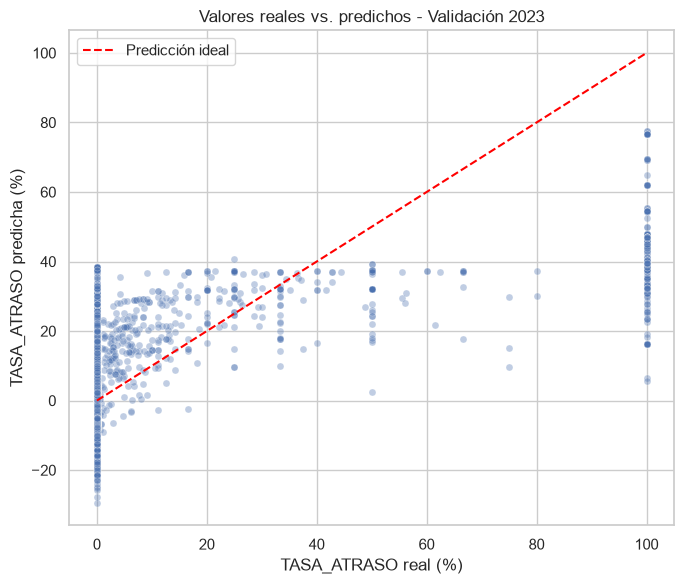

In [23]:
indices_grafico = pd.Series(y_valid_reg.index).sample(
    n=min(5_000, len(y_valid_reg)),
    random_state=42
)
reales_grafico = y_valid_reg.loc[indices_grafico]
predichos_grafico = pd.Series(
    pred_reg_2023,
    index=y_valid_reg.index
).loc[indices_grafico]

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x=reales_grafico,
    y=predichos_grafico,
    alpha=0.35,
    s=25
)
plt.plot([0, 100], [0, 100], "--", color="red", label="Predicción ideal")
plt.title("Valores reales vs. predichos - Validación 2023")
plt.xlabel("TASA_ATRASO real (%)")
plt.ylabel("TASA_ATRASO predicha (%)")
plt.legend()
plt.tight_layout()
plt.show()

Los puntos muestran una relación positiva, pero existe bastante dispersión alrededor de la línea ideal. El modelo tiene mayor dificultad para representar los valores extremos y puede producir algunas predicciones fuera del rango natural de una tasa.

# 8. Modelo / tarea 2

La segunda tarea compara cuatro clasificadores para predecir `HAY_ATRASO`.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

modelos_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

pipelines_clasificacion = {}
for nombre, modelo in modelos_clasificacion.items():
    pipeline = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento()),
        ("modelo", modelo)
    ])
    pipeline.fit(X_train_clas_m, y_train_clas_m)
    pipelines_clasificacion[nombre] = pipeline

print("Modelos entrenados:")
for nombre in pipelines_clasificacion:
    print("-", nombre)

Modelos entrenados:
- Regresión Logística
- KNN
- Árbol de Decisión
- Random Forest


Los cuatro modelos se entrenaron con las mismas variables y la misma muestra. De esta manera, las diferencias posteriores corresponden al comportamiento de cada algoritmo bajo condiciones comparables.

# 9. Evaluación

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

filas_metricas = []
predicciones_validacion = {}
probabilidades_validacion = {}

for nombre, pipeline in pipelines_clasificacion.items():
    prediccion = pipeline.predict(X_valid_clas_m)
    probabilidad = pipeline.predict_proba(X_valid_clas_m)[:, 1]
    predicciones_validacion[nombre] = prediccion
    probabilidades_validacion[nombre] = probabilidad

    filas_metricas.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_valid_clas_m, prediccion),
        "Precision": precision_score(y_valid_clas_m, prediccion, zero_division=0),
        "Recall": recall_score(y_valid_clas_m, prediccion, zero_division=0),
        "F1": f1_score(y_valid_clas_m, prediccion, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid_clas_m, probabilidad)
    })

resultados_clasificacion = pd.DataFrame(filas_metricas).round(4)
display(resultados_clasificacion)

# Se prioriza F1 y se usa ROC-AUC como segundo criterio, no Accuracy de forma aislada.
nombre_seleccionado = (
    resultados_clasificacion
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .iloc[0]["Modelo"]
)
modelo_seleccionado = pipelines_clasificacion[nombre_seleccionado]
print(f"Clasificador seleccionado: {nombre_seleccionado}")

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Regresión Logística,0.9166,0.7841,0.6167,0.6904,0.9441
1,KNN,0.9202,0.7569,0.6936,0.7239,0.9159
2,Árbol de Decisión,0.9240,0.8066,0.6525,0.7214,0.9162
3,Random Forest,0.9266,0.8121,0.6678,0.7329,0.9479


Clasificador seleccionado: Random Forest


Random Forest presenta el mejor F1 (0.7329), el mayor ROC-AUC (0.9479) y un Recall de 0.6678, manteniendo también una precisión alta. Por ese equilibrio se selecciona para la evaluación de 2024, no solamente por su Accuracy.

In [26]:
y_clas_2024 = df_modelo_2024["HAY_ATRASO"]
pred_clas_2024 = modelo_seleccionado.predict(X_2024)
proba_clas_2024 = modelo_seleccionado.predict_proba(X_2024)[:, 1]

resultados_clasificacion_2024 = pd.DataFrame([{
    "Modelo": nombre_seleccionado,
    "Conjunto": "Evaluación 2024",
    "Accuracy": accuracy_score(y_clas_2024, pred_clas_2024),
    "Precision": precision_score(y_clas_2024, pred_clas_2024, zero_division=0),
    "Recall": recall_score(y_clas_2024, pred_clas_2024, zero_division=0),
    "F1": f1_score(y_clas_2024, pred_clas_2024, zero_division=0),
    "ROC-AUC": roc_auc_score(y_clas_2024, proba_clas_2024)
}]).round(4)

display(resultados_clasificacion_2024)

,Modelo,Conjunto,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,Evaluación 2024,0.9281,0.8083,0.6486,0.7197,0.9423


En el periodo 2024, Random Forest alcanza un F1 de 0.7197 y un ROC-AUC de 0.9423. El desempeño se mantiene cercano al observado en la validación de 2023, aunque el Recall baja ligeramente a 0.6486.

### Matriz de confusión del modelo seleccionado

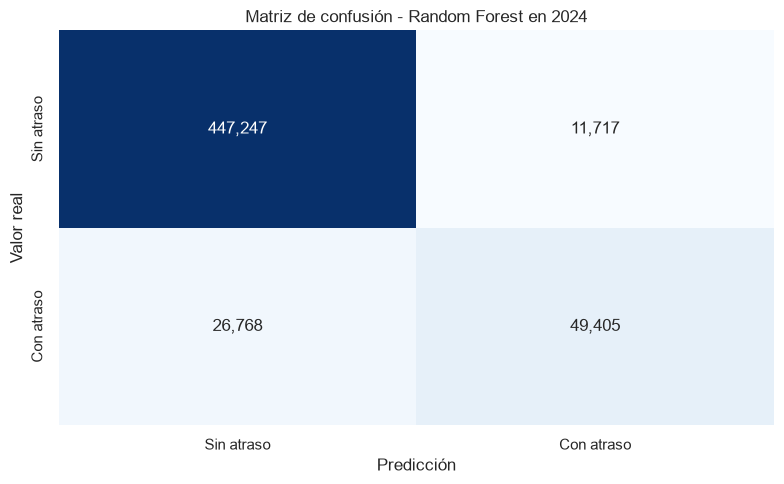

,Resultado,Cantidad
0,Verdaderos negativos,447247
1,Falsos positivos,11717
2,Falsos negativos,26768
3,Verdaderos positivos,49405


In [27]:
matriz_confusion = confusion_matrix(y_clas_2024, pred_clas_2024)

sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Sin atraso", "Con atraso"],
    yticklabels=["Sin atraso", "Con atraso"]
)
plt.title(f"Matriz de confusión - {nombre_seleccionado} en 2024")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = matriz_confusion.ravel()
display(pd.DataFrame({
    "Resultado": [
        "Verdaderos negativos", "Falsos positivos",
        "Falsos negativos", "Verdaderos positivos"
    ],
    "Cantidad": [tn, fp, fn, tp]
}))

La matriz muestra que el modelo identifica correctamente la mayor parte de los registros sin atraso y una proporción importante de los que sí presentan atraso. Los falsos negativos representan casos con atraso que el modelo clasificó como ausencia, por lo que explican que el Recall sea menor que la Precision.

### Curva ROC del modelo seleccionado

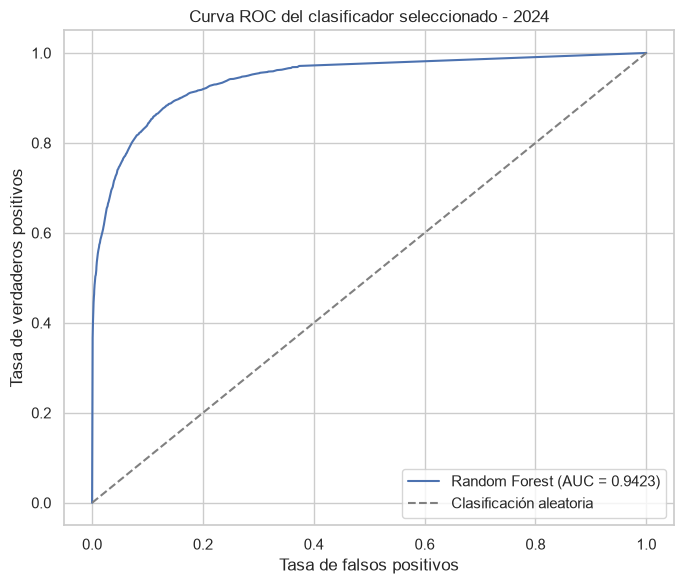

In [28]:
fpr, tpr, _ = roc_curve(y_clas_2024, proba_clas_2024)
auc_2024 = roc_auc_score(y_clas_2024, proba_clas_2024)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{nombre_seleccionado} (AUC = {auc_2024:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Clasificación aleatoria")
plt.title("Curva ROC del clasificador seleccionado - 2024")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

La curva se mantiene claramente por encima de la diagonal y el AUC es 0.9423. Esto indica una buena capacidad para ordenar los registros con y sin atraso a distintos umbrales de clasificación.

### Comparación gráfica de clasificadores

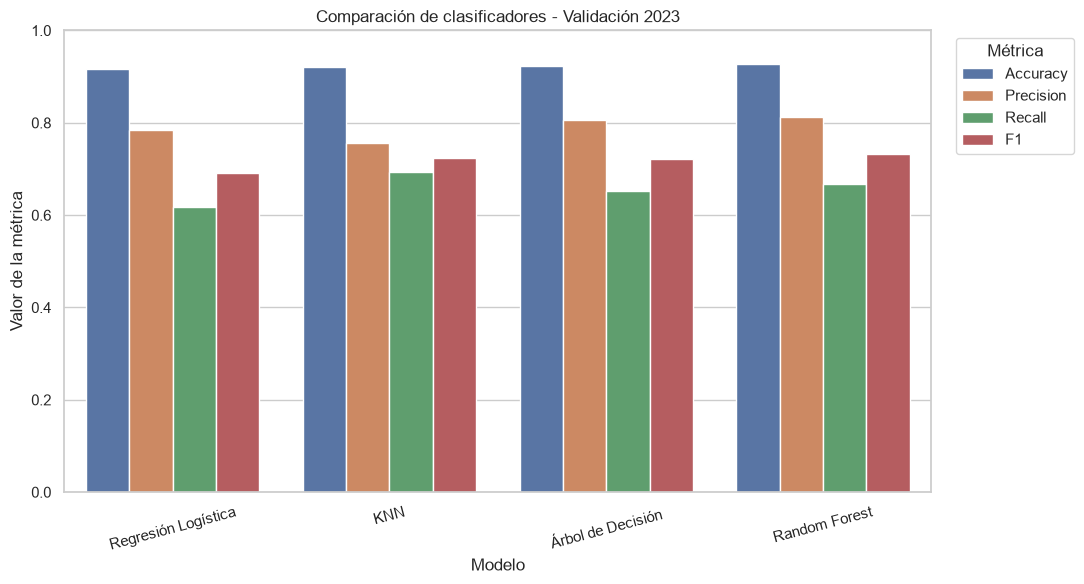

In [29]:
metricas_grafico = resultados_clasificacion.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Métrica",
    value_name="Valor"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=metricas_grafico, x="Modelo", y="Valor", hue="Métrica")
plt.title("Comparación de clasificadores - Validación 2023")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Los cuatro modelos superan 0.91 de Accuracy, pero las diferencias son más visibles en Recall y F1. Random Forest logra el mayor F1 y el mejor equilibrio general; KNN y el Árbol de Decisión quedan cerca, mientras que la Regresión Logística tiene el Recall más bajo.

# 10. Comparación de resultados

In [30]:
fila_regresion_2024 = resultados_regresion.loc[
    resultados_regresion["Conjunto"] == "Evaluación 2024"
].iloc[0]
fila_clasificacion_2024 = resultados_clasificacion_2024.iloc[0]

comparacion_final = pd.DataFrame([
    {
        "Tarea": "Regresión",
        "Modelo seleccionado": "Regresión Lineal",
        "Objetivo": "TASA_ATRASO",
        "Resultado principal": (
            f"MAE={fila_regresion_2024['MAE']:.4f}, "
            f"RMSE={fila_regresion_2024['RMSE']:.4f}, "
            f"R²={fila_regresion_2024['R²']:.4f}"
        )
    },
    {
        "Tarea": "Clasificación",
        "Modelo seleccionado": nombre_seleccionado,
        "Objetivo": "HAY_ATRASO",
        "Resultado principal": (
            f"F1={fila_clasificacion_2024['F1']:.4f}, "
            f"ROC-AUC={fila_clasificacion_2024['ROC-AUC']:.4f}"
        )
    }
])

display(comparacion_final)

,Tarea,Modelo seleccionado,Objetivo,Resultado principal
0,Regresión,Regresión Lineal,TASA_ATRASO,"MAE=14.1398, RMSE=20.2960, R²=0.3514"
1,Clasificación,Random Forest,HAY_ATRASO,"F1=0.7197, ROC-AUC=0.9423"


Las dos tareas responden preguntas diferentes: la regresión estima el porcentaje de atraso y la clasificación identifica su presencia. Por esa razón, R² no se compara directamente con Accuracy, F1 o ROC-AUC.

# 11. Conclusiones técnicas

1. El análisis utilizó 1,079,971 registros de 2023 y 2024. No se eliminaron filas porque no se encontraron duplicados exactos ni valores numéricos imposibles.
2. La tasa de atraso está muy concentrada en 0 %. Su media disminuyó de 8.80 % en 2023 a 7.91 % en 2024.
3. Secundaria presentó la mayor tasa media de atraso (17.77 %). La gestión pública directa también mostró una media superior a la gestión privada.
4. La Regresión Lineal superó al baseline, pero su capacidad explicativa fue moderada: obtuvo R² de 0.3823 en la validación de 2023 y 0.3514 en 2024.
5. Entre los cuatro clasificadores, Random Forest consiguió el mejor equilibrio en la validación de 2023, con F1 de 0.7329 y ROC-AUC de 0.9479.
6. En la evaluación de 2024, Random Forest mantuvo un desempeño parecido, con F1 de 0.7197 y ROC-AUC de 0.9423.
7. Como limitación, la clase con atraso representa solo 14.66 % de los registros y la comparación de clasificadores usó una muestra para reducir el costo computacional de KNN.

# 12. Verificación final de posibles fugas de información

Se comprueba con los datos si `Edad` y `dsc_nivel` están demasiado relacionadas con la forma en que se define el atraso.

## 1. Comprobar cómo se construye `tot_atraso`

In [31]:
condicion_cero = df_limpio["tot_atraso"] == 0
condicion_total = df_limpio["tot_atraso"] == df_limpio["TotalEstudiantes"]
condicion_parcial = (
    (df_limpio["tot_atraso"] > 0)
    & (df_limpio["tot_atraso"] < df_limpio["TotalEstudiantes"])
)

resumen_construccion = pd.DataFrame({
    "Situación": [
        "tot_atraso = 0",
        "tot_atraso = TotalEstudiantes",
        "0 < tot_atraso < TotalEstudiantes",
        "TASA_ATRASO = 0 %",
        "TASA_ATRASO = 100 %"
    ],
    "Cantidad": [
        condicion_cero.sum(),
        condicion_total.sum(),
        condicion_parcial.sum(),
        df_limpio["TASA_ATRASO"].eq(0).sum(),
        df_limpio["TASA_ATRASO"].eq(100).sum()
    ]
})
resumen_construccion["Porcentaje"] = (
    resumen_construccion["Cantidad"] / len(df_limpio) * 100
).round(4)
display(resumen_construccion)

frecuencias_tasa = (
    df_limpio["TASA_ATRASO"]
    .value_counts()
    .head(15)
    .rename_axis("TASA_ATRASO")
    .reset_index(name="Cantidad")
)
frecuencias_tasa["Porcentaje"] = (
    frecuencias_tasa["Cantidad"] / len(df_limpio) * 100
).round(4)

valores_unicos_tasa = np.sort(df_limpio["TASA_ATRASO"].dropna().unique())
vista_valores_unicos = np.concatenate([
    valores_unicos_tasa[:10],
    valores_unicos_tasa[-10:]
])

print(f"Cantidad de valores únicos de TASA_ATRASO: {len(valores_unicos_tasa):,}")
print("Primeros y últimos valores únicos:")
print(np.round(vista_valores_unicos, 4))
display(frecuencias_tasa)
display(df_limpio["TASA_ATRASO"].describe().to_frame().T)

,Situación,Cantidad,Porcentaje
0,tot_atraso = 0,921620,85.3375
1,tot_atraso = TotalEstudiantes,74210,6.8715
2,0 < tot_atraso < TotalEstudiantes,84141,7.7910
3,TASA_ATRASO = 0 %,921620,85.3375
4,TASA_ATRASO = 100 %,74210,6.8715


Cantidad de valores únicos de TASA_ATRASO: 2,617
Primeros y últimos valores únicos:
[  0.       0.1634   0.1658   0.1825   0.2041   0.2053   0.2128   0.2288
   0.2342   0.2387  92.3077  92.8571  93.3333  94.7368  95.2381  95.4545
  96.      96.1538  96.2963 100.    ]


,TASA_ATRASO,Cantidad,Porcentaje
0,0.000000,921620,85.3375
1,100.000000,74210,6.8715
2,50.000000,7125,0.6597
3,33.333333,5023,0.4651
4,25.000000,3783,0.3503
5,20.000000,3091,0.2862
6,16.666667,2614,0.2420
7,14.285714,2292,0.2122
8,12.500000,2051,0.1899
9,11.111111,1802,0.1669


,count,mean,std,min,25%,50%,75%,max
TASA_ATRASO,1079971.0,8.356635,25.917082,0.0,0.0,0.0,0.0,100.0


El 85.34 % de las filas tiene tasa 0 % y el 6.87 % tiene tasa 100 %; en conjunto, 92.21 % corresponde a ninguno o a todos los estudiantes del registro. Solo 7.79 % presenta una proporción intermedia, por lo que el objetivo es mayormente extremo y no una tasa gradual.

## 2. Relación entre Edad, nivel y atraso

In [32]:
resumen_edad_nivel = (
    df_limpio
    .groupby(["dsc_nivel", "Edad"], dropna=False, observed=True)
    .agg(
        Registros=("HAY_ATRASO", "size"),
        Tasa_media=("TASA_ATRASO", "mean"),
        Porcentaje_con_atraso=("HAY_ATRASO", "mean"),
        Tasa_minima=("TASA_ATRASO", "min"),
        Tasa_maxima=("TASA_ATRASO", "max")
    )
    .reset_index()
    .sort_values(["dsc_nivel", "Edad"], na_position="last")
)
resumen_edad_nivel["Porcentaje_con_atraso"] *= 100

grupos_casi_constantes = (
    (resumen_edad_nivel["Porcentaje_con_atraso"] <= 5)
    | (resumen_edad_nivel["Porcentaje_con_atraso"] >= 95)
)
porcentaje_grupos_constantes = grupos_casi_constantes.mean() * 100
porcentaje_registros_constantes = (
    resumen_edad_nivel.loc[grupos_casi_constantes, "Registros"].sum()
    / resumen_edad_nivel["Registros"].sum() * 100
)

with pd.option_context("display.max_rows", None):
    display(resumen_edad_nivel.round(4))

display(pd.DataFrame({
    "Indicador": [
        "Combinaciones analizadas",
        "Combinaciones con respuesta menor o igual a 5 % o mayor o igual a 95 %",
        "Registros dentro de esas combinaciones"
    ],
    "Resultado": [
        len(resumen_edad_nivel),
        f"{porcentaje_grupos_constantes:.2f} %",
        f"{porcentaje_registros_constantes:.2f} %"
    ]
}))

,dsc_nivel,Edad,Registros,Tasa_media,Porcentaje_con_atraso,Tasa_minima,Tasa_maxima
0,Inicial - Cuna,0.0,27,0.0000,0.0000,0.0,0.0
1,Inicial - Cuna,1.0,41,0.0000,0.0000,0.0,0.0
2,Inicial - Cuna,2.0,45,0.0000,0.0000,0.0,0.0
3,Inicial - Cuna,3.0,1,0.0000,0.0000,0.0,0.0
4,Inicial - Cuna-Jardín,0.0,395,0.0000,0.0000,0.0,0.0
5,Inicial - Cuna-Jardín,1.0,1551,0.0000,0.0000,0.0,0.0
6,Inicial - Cuna-Jardín,2.0,2551,0.0000,0.0000,0.0,0.0
7,Inicial - Cuna-Jardín,3.0,3788,0.0000,0.0000,0.0,0.0
8,Inicial - Cuna-Jardín,4.0,3949,0.0000,0.0000,0.0,0.0
9,Inicial - Cuna-Jardín,5.0,3965,0.0000,0.0000,0.0,0.0


,Indicador,Resultado
0,Combinaciones analizadas,66
1,Combinaciones con respuesta menor o igual a 5 ...,87.88 %
2,Registros dentro de esas combinaciones,61.18 %


El 87.88 % de las combinaciones de nivel y edad presenta atraso en menos de 5 % o en más de 95 % de sus registros. Se observan reglas muy marcadas: Inicial siempre queda en 0 %, Primaria desde los 13 años queda en 100 % y Secundaria a los 18 años también queda en 100 %.

## 3. Comprobar si Edad y nivel casi determinan el objetivo

In [33]:
def crear_preprocesamiento_para(predictores):
    numericas = [x for x in predictores if x not in ["gestion", "dsc_nivel"]]
    categoricas = [x for x in predictores if x in ["gestion", "dsc_nivel"]]
    transformadores = []

    if numericas:
        transformadores.append((
            "numericas",
            Pipeline(steps=[
                ("imputador", SimpleImputer(strategy="median")),
                ("escalador", StandardScaler())
            ]),
            numericas
        ))

    if categoricas:
        transformadores.append((
            "categoricas",
            Pipeline(steps=[
                ("imputador", SimpleImputer(strategy="most_frequent")),
                ("codificador", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categoricas
        ))

    return ColumnTransformer(transformers=transformadores)


predictores_experimentos = {
    "A. Predictores completos": variables_predictoras,
    "B. Sin Edad": [x for x in variables_predictoras if x != "Edad"],
    "C. Sin dsc_nivel": [x for x in variables_predictoras if x != "dsc_nivel"],
    "D. Sin Edad ni dsc_nivel": [
        x for x in variables_predictoras if x not in ["Edad", "dsc_nivel"]
    ]
}

In [34]:
resultados_experimentos_clasificacion = []

for experimento, predictores in predictores_experimentos.items():
    pipeline_experimento = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento_para(predictores)),
        ("modelo", RandomForestClassifier(random_state=42))
    ])
    pipeline_experimento.fit(
        X_train_clas_m[predictores],
        y_train_clas_m
    )
    prediccion = pipeline_experimento.predict(X_valid_clas_m[predictores])
    probabilidad = pipeline_experimento.predict_proba(
        X_valid_clas_m[predictores]
    )[:, 1]

    resultados_experimentos_clasificacion.append({
        "Experimento": experimento,
        "Accuracy": accuracy_score(y_valid_clas_m, prediccion),
        "Precision": precision_score(y_valid_clas_m, prediccion, zero_division=0),
        "Recall": recall_score(y_valid_clas_m, prediccion, zero_division=0),
        "F1": f1_score(y_valid_clas_m, prediccion, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid_clas_m, probabilidad)
    })

tabla_experimentos_clasificacion = pd.DataFrame(
    resultados_experimentos_clasificacion
).round(4)
display(tabla_experimentos_clasificacion)

,Experimento,Accuracy,Precision,Recall,F1,ROC-AUC
0,A. Predictores completos,0.9266,0.8121,0.6678,0.7329,0.9479
1,B. Sin Edad,0.8477,0.4889,0.2182,0.3017,0.8223
2,C. Sin dsc_nivel,0.9134,0.7614,0.6200,0.6835,0.9340
3,D. Sin Edad ni dsc_nivel,0.8445,0.3464,0.0351,0.0638,0.6303


Al retirar `Edad`, el F1 cae de 0.7329 a 0.3017; al retirar solo `dsc_nivel` baja a 0.6835. Sin ambas variables, el F1 queda en 0.0638 y el ROC-AUC en 0.6303, por lo que la mayor parte de la capacidad del modelo completo depende de edad y nivel.

## 4. Modelo utilizando solamente Edad y nivel

In [35]:
predictores_edad_nivel = ["Edad", "dsc_nivel"]

pipeline_edad_nivel = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento_para(predictores_edad_nivel)),
    ("modelo", RandomForestClassifier(random_state=42))
])
pipeline_edad_nivel.fit(
    X_train_clas_m[predictores_edad_nivel],
    y_train_clas_m
)

pred_edad_nivel = pipeline_edad_nivel.predict(
    X_valid_clas_m[predictores_edad_nivel]
)
proba_edad_nivel = pipeline_edad_nivel.predict_proba(
    X_valid_clas_m[predictores_edad_nivel]
)[:, 1]

resultado_edad_nivel = pd.DataFrame([{
    "Modelo": "Solo Edad y dsc_nivel",
    "Accuracy": accuracy_score(y_valid_clas_m, pred_edad_nivel),
    "Precision": precision_score(y_valid_clas_m, pred_edad_nivel, zero_division=0),
    "Recall": recall_score(y_valid_clas_m, pred_edad_nivel, zero_division=0),
    "F1": f1_score(y_valid_clas_m, pred_edad_nivel, zero_division=0),
    "ROC-AUC": roc_auc_score(y_valid_clas_m, proba_edad_nivel)
}]).round(4)
display(resultado_edad_nivel)

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Solo Edad y dsc_nivel,0.9081,0.8477,0.4761,0.6098,0.9427


Con solo `Edad` y `dsc_nivel`, el ROC-AUC es 0.9427, apenas 0.0052 menor que el modelo completo. El F1 es menor (0.6098), pero la capacidad de separación muy cercana confirma que estas dos variables concentran casi toda la señal predictiva.

## 5. Repetir la comprobación para regresión

In [36]:
resultados_experimentos_regresion = []

for experimento, predictores in predictores_experimentos.items():
    pipeline_experimento_reg = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento_para(predictores)),
        ("modelo", LinearRegression())
    ])
    pipeline_experimento_reg.fit(
        X_train_reg[predictores],
        y_train_reg
    )
    prediccion = pipeline_experimento_reg.predict(X_valid_reg[predictores])

    resultados_experimentos_regresion.append({
        "Modelo": experimento,
        "MAE": mean_absolute_error(y_valid_reg, prediccion),
        "RMSE": np.sqrt(mean_squared_error(y_valid_reg, prediccion)),
        "R²": r2_score(y_valid_reg, prediccion)
    })

tabla_experimentos_regresion = pd.DataFrame(
    resultados_experimentos_regresion
).round(4)
display(tabla_experimentos_regresion)

,Modelo,MAE,RMSE,R²
0,A. Predictores completos,14.5463,20.8999,0.3823
1,B. Sin Edad,14.5786,25.3017,0.0947
2,C. Sin dsc_nivel,14.9589,23.0543,0.2484
3,D. Sin Edad ni dsc_nivel,15.1254,26.2115,0.0285


En regresión, el R² baja de 0.3823 a 0.0947 al retirar `Edad`, y a 0.2484 al retirar `dsc_nivel`. Sin ambas variables queda en 0.0285, casi al nivel del baseline, lo que confirma una dependencia muy fuerte.

### Resultado de la revisión de leakage

**C. Objetivo prácticamente determinístico.** El 92.21 % de los registros tiene atraso igual a cero o al total del grupo, y `Edad + dsc_nivel` logra un ROC-AUC de 0.9427 frente a 0.9479 del modelo completo. Al retirar ambas variables, el F1 de clasificación cae de 0.7329 a 0.0638 y el R² de regresión de 0.3823 a 0.0285; por ello existe un riesgo metodológico importante de que estas variables reproduzcan la regla usada para construir el atraso.

# 13. Reentrenamiento final del clasificador

Se crea una versión alternativa sin `Edad` ni `dsc_nivel`, porque ambas variables, en conjunto, están demasiado vinculadas con la definición del objetivo.

In [37]:
variables_finales = [
    variable for variable in variables_predictoras
    if variable not in ["Edad", "dsc_nivel"]
]

display(pd.DataFrame({
    "Conjunto": ["Predictores anteriores", "Predictores finales"],
    "Variables": [
        ", ".join(variables_predictoras),
        ", ".join(variables_finales)
    ]
}))

,Conjunto,Variables
0,Predictores anteriores,"Edad, TotalEstudiantes, Discapacidad, Venezola..."
1,Predictores finales,"TotalEstudiantes, Discapacidad, Venezolanos, E..."


In [38]:
# Se reentrena solo Random Forest con todos los registros de 2023.
X_final_2023 = df_modelo_2023[variables_finales]
y_final_2023 = df_modelo_2023["HAY_ATRASO"]
X_final_2024 = df_modelo_2024[variables_finales]
y_final_2024 = df_modelo_2024["HAY_ATRASO"]

pipeline_random_forest_final = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento_para(variables_finales)),
    ("modelo", RandomForestClassifier(random_state=42))
])
pipeline_random_forest_final.fit(X_final_2023, y_final_2023)

pred_random_forest_final = pipeline_random_forest_final.predict(X_final_2024)
proba_random_forest_final = pipeline_random_forest_final.predict_proba(
    X_final_2024
)[:, 1]

metricas_random_forest_final = {
    "Accuracy": accuracy_score(y_final_2024, pred_random_forest_final),
    "Precision": precision_score(
        y_final_2024, pred_random_forest_final, zero_division=0
    ),
    "Recall": recall_score(y_final_2024, pred_random_forest_final, zero_division=0),
    "F1": f1_score(y_final_2024, pred_random_forest_final, zero_division=0),
    "ROC-AUC": roc_auc_score(y_final_2024, proba_random_forest_final)
}

fila_anterior = resultados_clasificacion_2024.iloc[0]
comparacion_random_forest = pd.DataFrame([
    {
        "Modelo": "Random Forest anterior",
        "Datos usados para entrenamiento": "Muestra de 30,000 registros",
        "Accuracy": fila_anterior["Accuracy"],
        "Precision": fila_anterior["Precision"],
        "Recall": fila_anterior["Recall"],
        "F1": fila_anterior["F1"],
        "ROC-AUC": fila_anterior["ROC-AUC"]
    },
    {
        "Modelo": "Random Forest final",
        "Datos usados para entrenamiento": f"2023 completo ({len(X_final_2023):,})",
        **metricas_random_forest_final
    }
]).round(4)

display(comparacion_random_forest)

,Modelo,Datos usados para entrenamiento,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest anterior,"Muestra de 30,000 registros",0.9281,0.8083,0.6486,0.7197,0.9423
1,Random Forest final,"2023 completo (544,834)",0.8568,0.4609,0.0354,0.0657,0.6470


El modelo final usa más datos, pero obtiene resultados inferiores porque ya no dispone de las variables que casi reconstruían el objetivo. Esta reducción no se interpreta como un problema de entrenamiento, sino como una estimación más prudente de lo que aportan las variables restantes.

### Matriz de confusión del Random Forest final

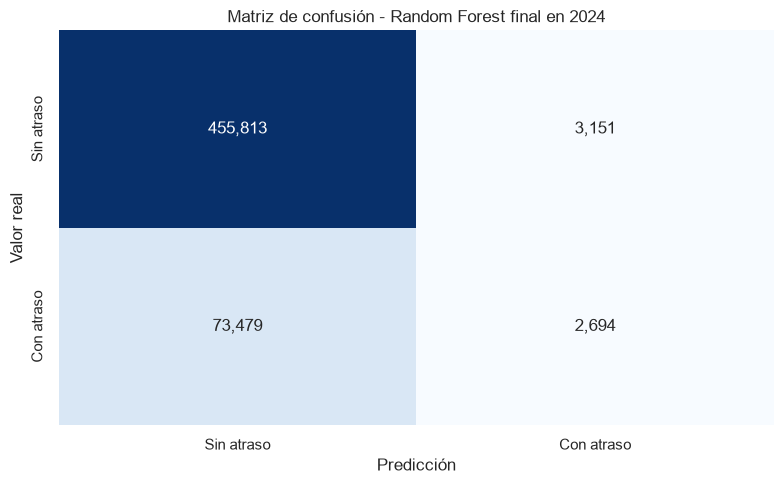

,Resultado,Cantidad
0,Verdaderos negativos,455813
1,Falsos positivos,3151
2,Falsos negativos,73479
3,Verdaderos positivos,2694


In [39]:
matriz_final = confusion_matrix(y_final_2024, pred_random_forest_final)

sns.heatmap(
    matriz_final,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Sin atraso", "Con atraso"],
    yticklabels=["Sin atraso", "Con atraso"]
)
plt.title("Matriz de confusión - Random Forest final en 2024")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

tn_final, fp_final, fn_final, tp_final = matriz_final.ravel()
display(pd.DataFrame({
    "Resultado": [
        "Verdaderos negativos", "Falsos positivos",
        "Falsos negativos", "Verdaderos positivos"
    ],
    "Cantidad": [tn_final, fp_final, fn_final, tp_final]
}))

# 14. Conclusión técnica definitiva

1. `Edad` y `dsc_nivel` presentan un riesgo metodológico importante: juntos logran ROC-AUC de 0.9427 y el 92.21 % de los registros tiene atraso igual a cero o al total del grupo.
2. El conjunto final más defendible conserva `TotalEstudiantes`, `Discapacidad`, `Venezolanos`, `Extranjeros` y `gestion`, excluyendo `Edad` y `dsc_nivel`.
3. Random Forest no mejoró al usar más registros de 2023. Al retirar las variables problemáticas, el F1 bajó de 0.7197 a 0.0657 y el ROC-AUC de 0.9423 a 0.6470.
4. Las métricas finales sobre 2024 fueron Accuracy 0.8568, Precision 0.4609, Recall 0.0354, F1 0.0657 y ROC-AUC 0.6470.
5. La afirmación segura es que el análisis identifica patrones asociados con la presencia de atraso escolar en registros educativos agregados y evalúa su generalización en un periodo posterior. Sin `Edad` y `dsc_nivel`, la capacidad para detectar registros con atraso es limitada; no corresponde afirmar que se predice qué estudiante tendrá atraso en el futuro.


# 15. Evaluación de objetivos alternativos

Se revisan variables de trayectoria y rendimiento escolar para encontrar objetivos que no repitan el problema detectado con `tot_atraso`.

## 1. Revisar distribución

In [40]:
variables_candidatas = [
    "Desaprobado", "Retirado", "RequiereRecuperacion",
    "PostergaEvaluacion", "Aprobado"
]

variables_existentes = [
    variable for variable in variables_candidatas
    if variable in df_limpio.columns
]
print("Variables encontradas:", variables_existentes)

filas_distribucion = []
for anio in [2023, 2024]:
    datos_anio = df_limpio[df_limpio["ANIO"] == anio]
    for variable in variables_existentes:
        serie = datos_anio[variable]
        filas_distribucion.append({
            "Año": anio,
            "Variable": variable,
            "Registros": len(serie),
            "Mínimo": serie.min(),
            "Máximo": serie.max(),
            "Media": serie.mean(),
            "Mediana": serie.median(),
            "% igual a 0": serie.eq(0).mean() * 100,
            "% mayor que 0": serie.gt(0).mean() * 100,
            "Nulos": serie.isna().sum()
        })

resumen_objetivos = pd.DataFrame(filas_distribucion).round(4)
display(resumen_objetivos)

Variables encontradas: ['Desaprobado', 'Retirado', 'RequiereRecuperacion', 'PostergaEvaluacion', 'Aprobado']


,Año,Variable,Registros,Mínimo,Máximo,Media,Mediana,% igual a 0,% mayor que 0,Nulos
0,2023,Desaprobado,544834,0,117,0.4598,0.0,85.9777,14.0223,0
1,2023,Retirado,544834,0,52,0.1274,0.0,93.9433,6.0567,0
2,2023,RequiereRecuperacion,544834,0,75,0.0096,0.0,99.4905,0.5095,0
3,2023,PostergaEvaluacion,544834,0,12,0.0017,0.0,99.9148,0.0852,0
4,2023,Aprobado,544834,0,713,14.5376,5.0,2.0357,97.9643,0
5,2024,Desaprobado,535137,0,108,0.4509,0.0,86.4040,13.5960,0
6,2024,Retirado,535137,0,57,0.0962,0.0,95.3657,4.6343,0
7,2024,RequiereRecuperacion,535137,0,132,0.0552,0.0,98.5968,1.4032,0
8,2024,PostergaEvaluacion,535137,0,25,0.0013,0.0,99.9316,0.0684,0
9,2024,Aprobado,535137,0,674,14.5994,5.0,2.2030,97.7970,0


`Desaprobado` tiene valores positivos en 14.02 % de los registros de 2023 y 13.60 % de 2024. `Retirado` presenta 6.06 % y 4.63 %, mientras que `RequiereRecuperacion` y `PostergaEvaluacion` son mucho más escasas; ninguna de las variables tiene nulos.

In [41]:
tasas_exploratorias = {
    "TASA_DESAPROBACION": "Desaprobado",
    "TASA_RETIRO": "Retirado",
    "TASA_RECUPERACION": "RequiereRecuperacion"
}

for tasa, numerador in tasas_exploratorias.items():
    df_limpio[tasa] = np.where(
        df_limpio["TotalEstudiantes"] > 0,
        df_limpio[numerador] / df_limpio["TotalEstudiantes"] * 100,
        np.nan
    )

resumen_tasas = []
for tasa in tasas_exploratorias:
    resumen_tasas.append({
        "Tasa": tasa,
        "Mínimo": df_limpio[tasa].min(),
        "Máximo": df_limpio[tasa].max(),
        "Media": df_limpio[tasa].mean(),
        "Mediana": df_limpio[tasa].median(),
        "% igual a 0": df_limpio[tasa].eq(0).mean() * 100,
        "% mayor que 0": df_limpio[tasa].gt(0).mean() * 100,
        "Casos mayores a 100 %": df_limpio[tasa].gt(100).sum()
    })

display(pd.DataFrame(resumen_tasas).round(4))

,Tasa,Mínimo,Máximo,Media,Mediana,% igual a 0,% mayor que 0,Casos mayores a 100 %
0,TASA_DESAPROBACION,0.0,100.0,3.4690,0.0,86.1890,13.8110,0
1,TASA_RETIRO,0.0,100.0,1.0632,0.0,94.6481,5.3519,0
2,TASA_RECUPERACION,0.0,100.0,0.2197,0.0,99.0477,0.9523,0


Las tres tasas se encuentran entre 0 % y 100 %, por lo que los cocientes son matemáticamente consistentes. `TASA_DESAPROBACION` tiene mayor presencia de valores positivos; `TASA_RETIRO` es más dispersa y `TASA_RECUPERACION` permanece en cero en 99.05 % de los registros.

## 2. Comprobar posibles relaciones determinísticas

In [42]:
columnas_resultado = [
    "Aprobado", "Desaprobado", "Retirado", "Fallecido",
    "RequiereRecuperacion", "Matriculado", "PostergaEvaluacion"
]

df_limpio["SUMA_ESTADOS"] = df_limpio[columnas_resultado].sum(axis=1)
df_limpio["SUMA_SIN_POSTERGA"] = df_limpio[
    [x for x in columnas_resultado if x != "PostergaEvaluacion"]
].sum(axis=1)

comprobacion_sumas = pd.DataFrame({
    "Relación comprobada": [
        "Suma de los siete estados = TotalEstudiantes",
        "Suma sin PostergaEvaluacion = TotalEstudiantes"
    ],
    "Filas que cumplen": [
        df_limpio["SUMA_ESTADOS"].eq(df_limpio["TotalEstudiantes"]).sum(),
        df_limpio["SUMA_SIN_POSTERGA"].eq(
            df_limpio["TotalEstudiantes"]
        ).sum()
    ]
})
comprobacion_sumas["Porcentaje"] = (
    comprobacion_sumas["Filas que cumplen"] / len(df_limpio) * 100
).round(4)
display(comprobacion_sumas)

print(
    "Relación exacta: TotalEstudiantes = Aprobado + Desaprobado + Retirado "
    "+ Fallecido + RequiereRecuperacion + Matriculado + PostergaEvaluacion"
)

,Relación comprobada,Filas que cumplen,Porcentaje
0,Suma de los siete estados = TotalEstudiantes,1079971,100.0000
1,Suma sin PostergaEvaluacion = TotalEstudiantes,1079141,99.9231


Relación exacta: TotalEstudiantes = Aprobado + Desaprobado + Retirado + Fallecido + RequiereRecuperacion + Matriculado + PostergaEvaluacion


La suma de los siete estados reproduce `TotalEstudiantes` en el 100 % de las filas. Por lo tanto, al modelar cualquiera de estos resultados se deben excluir todos los demás estados académicos y administrativos que permitan despejarlo mediante esa igualdad.

## 3. Objetivos candidatos de clasificación

In [43]:
df_limpio["HAY_DESAPROBACION"] = (df_limpio["Desaprobado"] > 0).astype(int)
df_limpio["HAY_RETIRO"] = (df_limpio["Retirado"] > 0).astype(int)
df_limpio["HAY_RECUPERACION"] = (
    df_limpio["RequiereRecuperacion"] > 0
).astype(int)

objetivos_clasificacion_alt = [
    "HAY_DESAPROBACION", "HAY_RETIRO", "HAY_RECUPERACION"
]

filas_clases = []
for objetivo in objetivos_clasificacion_alt:
    conteos = df_limpio[objetivo].value_counts().sort_index()
    for clase, cantidad in conteos.items():
        filas_clases.append({
            "Objetivo": objetivo,
            "Clase": clase,
            "Cantidad": cantidad,
            "Porcentaje": cantidad / len(df_limpio) * 100
        })

distribucion_objetivos_alt = pd.DataFrame(filas_clases).round(4)
display(distribucion_objetivos_alt)

,Objetivo,Clase,Cantidad,Porcentaje
0,HAY_DESAPROBACION,0,930816,86.1890
1,HAY_DESAPROBACION,1,149155,13.8110
2,HAY_RETIRO,0,1022172,94.6481
3,HAY_RETIRO,1,57799,5.3519
4,HAY_RECUPERACION,0,1069686,99.0477
5,HAY_RECUPERACION,1,10285,0.9523


`HAY_DESAPROBACION` tiene 13.81 % de casos positivos y ofrece el mejor balance. `HAY_RETIRO` tiene 5.35 % y puede estudiarse con cautela; `HAY_RECUPERACION`, con solo 0.95 %, se descarta por la escasez de la clase positiva.

## 4. Verificar que Edad y nivel no definan directamente estos objetivos

In [44]:
predictores_contextuales_alt = [
    "Edad", "TotalEstudiantes", "Discapacidad", "Venezolanos",
    "Extranjeros", "gestion", "dsc_nivel"
]
objetivos_viables_clasificacion = ["HAY_DESAPROBACION", "HAY_RETIRO"]

resultados_auc_alternativos = []

for objetivo in objetivos_viables_clasificacion:
    datos_2023_alt = df_limpio[df_limpio["ANIO"] == 2023]
    X_alt = datos_2023_alt[predictores_contextuales_alt]
    y_alt = datos_2023_alt[objetivo]

    X_train_alt, X_valid_alt, y_train_alt, y_valid_alt = train_test_split(
        X_alt,
        y_alt,
        test_size=0.20,
        random_state=42,
        stratify=y_alt
    )
    X_train_alt, y_train_alt = muestra_estratificada(
        X_train_alt, y_train_alt, 30_000
    )
    X_valid_alt, y_valid_alt = muestra_estratificada(
        X_valid_alt, y_valid_alt, 10_000
    )

    conjuntos_predictores = {
        "Solo Edad y dsc_nivel": ["Edad", "dsc_nivel"],
        "Predictores contextuales": predictores_contextuales_alt
    }

    for tipo_modelo, predictores in conjuntos_predictores.items():
        pipeline_alt = Pipeline(steps=[
            ("preprocesamiento", crear_preprocesamiento_para(predictores)),
            ("modelo", RandomForestClassifier(random_state=42))
        ])
        pipeline_alt.fit(X_train_alt[predictores], y_train_alt)
        probabilidad_alt = pipeline_alt.predict_proba(
            X_valid_alt[predictores]
        )[:, 1]

        resultados_auc_alternativos.append({
            "Objetivo": objetivo,
            "Modelo": tipo_modelo,
            "ROC-AUC": roc_auc_score(y_valid_alt, probabilidad_alt)
        })

tabla_auc_alternativos = pd.DataFrame(resultados_auc_alternativos).round(4)
display(tabla_auc_alternativos)

,Objetivo,Modelo,ROC-AUC
0,HAY_DESAPROBACION,Solo Edad y dsc_nivel,0.7601
1,HAY_DESAPROBACION,Predictores contextuales,0.8586
2,HAY_RETIRO,Solo Edad y dsc_nivel,0.6681
3,HAY_RETIRO,Predictores contextuales,0.7126


`Edad + dsc_nivel` obtiene ROC-AUC de 0.7601 para desaprobación y 0.6681 para retiro, lejos del 0.9427 observado con atraso. Los predictores contextuales mejoran a 0.8586 y 0.7126, por lo que ambos objetivos contienen información que no se reduce a una regla de edad y nivel.

## 5. Evaluar dos tareas complementarias

La clasificación más defendible es `HAY_DESAPROBACION`, porque conserva una clase positiva de 13.81 % y no queda determinada por edad y nivel. Como tarea complementaria de regresión se propone `TASA_RETIRO`: estudia una dimensión distinta de la trayectoria escolar, aunque su alta concentración en cero deberá considerarse al evaluar el modelo.

## 6. Recomendación técnica

In [45]:
recomendacion_objetivos = pd.DataFrame([
    {
        "Objetivo candidato": "TASA_DESAPROBACION",
        "Tipo": "Regresión",
        "Balance adecuado": "Sí, aunque 86.19 % son ceros",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No; AUC de presencia = 0.7601",
        "Viable": "Sí"
    },
    {
        "Objetivo candidato": "TASA_RETIRO",
        "Tipo": "Regresión",
        "Balance adecuado": "Limitado; 94.65 % son ceros",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No; AUC de presencia = 0.6681",
        "Viable": "Sí, con cautela"
    },
    {
        "Objetivo candidato": "TASA_RECUPERACION",
        "Tipo": "Regresión",
        "Balance adecuado": "No; 99.05 % son ceros",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No evaluado por baja presencia",
        "Viable": "No"
    },
    {
        "Objetivo candidato": "HAY_DESAPROBACION",
        "Tipo": "Clasificación",
        "Balance adecuado": "Sí; 13.81 % positivos",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No; ROC-AUC = 0.7601",
        "Viable": "Sí"
    },
    {
        "Objetivo candidato": "HAY_RETIRO",
        "Tipo": "Clasificación",
        "Balance adecuado": "Limitado; 5.35 % positivos",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No; ROC-AUC = 0.6681",
        "Viable": "Sí, con cautela"
    },
    {
        "Objetivo candidato": "HAY_RECUPERACION",
        "Tipo": "Clasificación",
        "Balance adecuado": "No; 0.95 % positivos",
        "Riesgo de leakage": "Controlable si se excluyen los otros estados",
        "Edad+nivel lo determinan": "No evaluado por baja presencia",
        "Viable": "No"
    }
])

display(recomendacion_objetivos)

,Objetivo candidato,Tipo,Balance adecuado,Riesgo de leakage,Edad+nivel lo determinan,Viable
0,TASA_DESAPROBACION,Regresión,"Sí, aunque 86.19 % son ceros",Controlable si se excluyen los otros estados,No; AUC de presencia = 0.7601,Sí
1,TASA_RETIRO,Regresión,Limitado; 94.65 % son ceros,Controlable si se excluyen los otros estados,No; AUC de presencia = 0.6681,"Sí, con cautela"
2,TASA_RECUPERACION,Regresión,No; 99.05 % son ceros,Controlable si se excluyen los otros estados,No evaluado por baja presencia,No
3,HAY_DESAPROBACION,Clasificación,Sí; 13.81 % positivos,Controlable si se excluyen los otros estados,No; ROC-AUC = 0.7601,Sí
4,HAY_RETIRO,Clasificación,Limitado; 5.35 % positivos,Controlable si se excluyen los otros estados,No; ROC-AUC = 0.6681,"Sí, con cautela"
5,HAY_RECUPERACION,Clasificación,No; 0.95 % positivos,Controlable si se excluyen los otros estados,No evaluado por baja presencia,No


### Tareas recomendadas

1. **Clasificación:** predecir `HAY_DESAPROBACION` con predictores contextuales y sin utilizar ninguna variable de resultado académico.
2. **Regresión:** estimar `TASA_RETIRO`, también excluyendo todos los estados que forman la suma de `TotalEstudiantes`.

Estas tareas estudian fenómenos distintos, están disponibles en 2023 y 2024 y no quedan prácticamente determinadas por `Edad + dsc_nivel`. No se entrenan todavía los modelos finales.

# 16. Comprobación final de viabilidad de los objetivos

## 1. Influencia de TotalEstudiantes en HAY_DESAPROBACION

In [46]:
predictores_contextuales_finales = [
    "Edad", "TotalEstudiantes", "Discapacidad", "Venezolanos",
    "Extranjeros", "gestion", "dsc_nivel"
]
predictores_sin_total = [
    x for x in predictores_contextuales_finales if x != "TotalEstudiantes"
]

datos_2023_final = df_limpio[df_limpio["ANIO"] == 2023]
X_viabilidad = datos_2023_final[predictores_contextuales_finales]
y_viabilidad = datos_2023_final["HAY_DESAPROBACION"]

X_train_v, X_valid_v, y_train_v, y_valid_v = train_test_split(
    X_viabilidad, y_viabilidad, test_size=0.20,
    random_state=42, stratify=y_viabilidad
)
X_train_v_m, y_train_v_m = muestra_estratificada(
    X_train_v, y_train_v, 30_000
)
X_valid_v_m, y_valid_v_m = muestra_estratificada(
    X_valid_v, y_valid_v, 10_000
)

modelos_tamano = {
    "A. Solo TotalEstudiantes": ["TotalEstudiantes"],
    "B. Contextuales completos": predictores_contextuales_finales,
    "C. Contextuales sin TotalEstudiantes": predictores_sin_total
}

filas_tamano = []
for nombre, predictores in modelos_tamano.items():
    modelo = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento_para(predictores)),
        ("modelo", RandomForestClassifier(random_state=42))
    ])
    modelo.fit(X_train_v_m[predictores], y_train_v_m)
    pred = modelo.predict(X_valid_v_m[predictores])
    proba = modelo.predict_proba(X_valid_v_m[predictores])[:, 1]
    filas_tamano.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_valid_v_m, pred),
        "Precision": precision_score(y_valid_v_m, pred, zero_division=0),
        "Recall": recall_score(y_valid_v_m, pred, zero_division=0),
        "F1": f1_score(y_valid_v_m, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid_v_m, proba)
    })

comparacion_tamano = pd.DataFrame(filas_tamano).round(4)
display(comparacion_tamano)

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,A. Solo TotalEstudiantes,0.8618,0.5355,0.1077,0.1793,0.7269
1,B. Contextuales completos,0.8835,0.6476,0.3709,0.4717,0.8586
2,C. Contextuales sin TotalEstudiantes,0.8743,0.7089,0.1755,0.2813,0.8433


`TotalEstudiantes` por sí solo obtiene F1 de 0.1793, por lo que no explica casi exclusivamente el objetivo. Sin esta variable, el ROC-AUC baja poco (0.8586 a 0.8433), pero Recall cae de 0.3709 a 0.1755; se conserva como una medida contextual de exposición, no como una reconstrucción directa del resultado.

## 2. Viabilidad de TASA_RETIRO para Regresión Lineal

In [47]:
X_reg_alt = datos_2023_final[predictores_contextuales_finales]
y_retiro_2023 = datos_2023_final["TASA_RETIRO"]

X_train_ret, X_valid_ret, y_train_ret, y_valid_ret = train_test_split(
    X_reg_alt, y_retiro_2023, test_size=0.20, random_state=42
)

pipeline_retiro = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento_para(predictores_contextuales_finales)),
    ("modelo", LinearRegression())
])
pipeline_retiro.fit(X_train_ret, y_train_ret)
pred_retiro = pipeline_retiro.predict(X_valid_ret)
baseline_retiro = np.repeat(y_train_ret.mean(), len(y_valid_ret))

comparacion_retiro = pd.DataFrame([
    {
        "Modelo": "Regresión Lineal",
        "MAE": mean_absolute_error(y_valid_ret, pred_retiro),
        "RMSE": np.sqrt(mean_squared_error(y_valid_ret, pred_retiro)),
        "R²": r2_score(y_valid_ret, pred_retiro),
        "% predicciones < 0": (pred_retiro < 0).mean() * 100,
        "% predicciones > 100": (pred_retiro > 100).mean() * 100
    },
    {
        "Modelo": "Baseline de la media",
        "MAE": mean_absolute_error(y_valid_ret, baseline_retiro),
        "RMSE": np.sqrt(mean_squared_error(y_valid_ret, baseline_retiro)),
        "R²": r2_score(y_valid_ret, baseline_retiro),
        "% predicciones < 0": 0,
        "% predicciones > 100": 0
    }
]).round(4)
display(comparacion_retiro)

,Modelo,MAE,RMSE,R²,% predicciones < 0,% predicciones > 100
0,Regresión Lineal,2.3409,8.3813,0.0244,16.539,0.0
1,Baseline de la media,2.2756,8.4856,-0.0000,0.000,0.0


La Regresión Lineal de retiro obtiene R² de 0.0244 y mejora ligeramente el RMSE del baseline, pero su MAE es peor. Además, 16.54 % de las predicciones son negativas, por lo que `TASA_RETIRO` no resulta adecuada para cerrar el proyecto con este modelo.

## 3. Comparación alternativa con TASA_DESAPROBACION

In [48]:
def evaluar_regresion_provisional(objetivo):
    y_objetivo = datos_2023_final[objetivo]
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_reg_alt, y_objetivo, test_size=0.20, random_state=42
    )
    pipeline = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento_para(predictores_contextuales_finales)),
        ("modelo", LinearRegression())
    ])
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_valid)
    baseline = np.repeat(y_train.mean(), len(y_valid))
    return {
        "Objetivo": objetivo,
        "% ceros": datos_2023_final[objetivo].eq(0).mean() * 100,
        "MAE": mean_absolute_error(y_valid, pred),
        "RMSE": np.sqrt(mean_squared_error(y_valid, pred)),
        "R²": r2_score(y_valid, pred),
        "% predicciones negativas": (pred < 0).mean() * 100,
        "% predicciones > 100": (pred > 100).mean() * 100,
        "MAE baseline": mean_absolute_error(y_valid, baseline),
        "RMSE baseline": np.sqrt(mean_squared_error(y_valid, baseline))
    }

comparacion_objetivos_reg = pd.DataFrame([
    evaluar_regresion_provisional("TASA_RETIRO"),
    evaluar_regresion_provisional("TASA_DESAPROBACION")
]).round(4)
display(comparacion_objetivos_reg)

,Objetivo,% ceros,MAE,RMSE,R²,% predicciones negativas,% predicciones > 100,MAE baseline,RMSE baseline
0,TASA_RETIRO,93.9433,2.3409,8.3813,0.0244,16.5390,0.0,2.2756,8.4856
1,TASA_DESAPROBACION,85.9777,6.0723,13.5676,0.0705,17.9825,0.0,6.1562,14.0728


`TASA_DESAPROBACION` sigue concentrada en cero, pero mejora tanto MAE como RMSE frente al baseline y alcanza R² de 0.0705. También produce 17.98 % de predicciones negativas; por ello es la alternativa más razonable entre las dos, aunque su capacidad explicativa continúa siendo baja.

# 17. Decisión definitiva de las dos tareas

- **Clasificación:** se conserva `HAY_DESAPROBACION`. `TotalEstudiantes` se mantiene porque aporta información contextual y no determina por sí solo el objetivo.
- **Regresión:** se selecciona `TASA_DESAPROBACION`. Supera al baseline de forma más consistente que `TASA_RETIRO`, aunque estudiar presencia y magnitud de la desaprobación reduce la complementariedad entre tareas.

La regresión se conserva como una estimación exploratoria de magnitud, con la limitación de un R² bajo y predicciones negativas.

# 18. Entrenamiento definitivo

## Tarea 1 — Clasificación de HAY_DESAPROBACION

In [49]:
X_clas_2023 = datos_2023_final[predictores_contextuales_finales]
y_clas_2023_final = datos_2023_final["HAY_DESAPROBACION"]

X_train_clas_final, X_valid_clas_final, y_train_clas_final, y_valid_clas_final = train_test_split(
    X_clas_2023, y_clas_2023_final, test_size=0.20,
    random_state=42, stratify=y_clas_2023_final
)
X_train_clas_comp, y_train_clas_comp = muestra_estratificada(
    X_train_clas_final, y_train_clas_final, 30_000
)
X_valid_clas_comp, y_valid_clas_comp = muestra_estratificada(
    X_valid_clas_final, y_valid_clas_final, 10_000
)

modelos_finales_clasificacion = {
    "Regresión Logística": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

filas_modelos_finales = []
pipelines_modelos_finales = {}
for nombre, estimador in modelos_finales_clasificacion.items():
    pipeline = Pipeline(steps=[
        ("preprocesamiento", crear_preprocesamiento_para(predictores_contextuales_finales)),
        ("modelo", estimador)
    ])
    pipeline.fit(X_train_clas_comp, y_train_clas_comp)
    pred = pipeline.predict(X_valid_clas_comp)
    proba = pipeline.predict_proba(X_valid_clas_comp)[:, 1]
    pipelines_modelos_finales[nombre] = pipeline
    filas_modelos_finales.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_valid_clas_comp, pred),
        "Precision": precision_score(y_valid_clas_comp, pred, zero_division=0),
        "Recall": recall_score(y_valid_clas_comp, pred, zero_division=0),
        "F1": f1_score(y_valid_clas_comp, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_valid_clas_comp, proba)
    })

resultados_modelos_finales = pd.DataFrame(filas_modelos_finales).round(4)
display(resultados_modelos_finales)

nombre_clasificador_final = (
    resultados_modelos_finales
    .sort_values(["F1", "ROC-AUC"], ascending=False)
    .iloc[0]["Modelo"]
)
print("Clasificador seleccionado:", nombre_clasificador_final)

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Regresión Logística,0.8769,0.6904,0.2211,0.3350,0.8512
1,KNN,0.8720,0.5655,0.3759,0.4516,0.8005
2,Árbol de Decisión,0.8815,0.6449,0.3445,0.4491,0.7959
3,Random Forest,0.8835,0.6476,0.3709,0.4717,0.8586


Clasificador seleccionado: Random Forest


Random Forest presenta el mayor F1 (0.4717) y ROC-AUC (0.8586), con Recall de 0.3709. KNN obtiene un Recall ligeramente mayor, pero Random Forest ofrece el mejor equilibrio entre las métricas principales.

In [50]:
# Se reentrena el modelo seleccionado con todo el entrenamiento de 2023.
pipeline_clasificador_final = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento_para(predictores_contextuales_finales)),
    ("modelo", RandomForestClassifier(random_state=42))
])
pipeline_clasificador_final.fit(X_train_clas_final, y_train_clas_final)

datos_2024_final = df_limpio[df_limpio["ANIO"] == 2024]
X_clas_2024 = datos_2024_final[predictores_contextuales_finales]
y_clas_2024_final = datos_2024_final["HAY_DESAPROBACION"]
pred_clas_final_2024 = pipeline_clasificador_final.predict(X_clas_2024)
proba_clas_final_2024 = pipeline_clasificador_final.predict_proba(X_clas_2024)[:, 1]

metricas_clas_2024_final = {
    "Accuracy": accuracy_score(y_clas_2024_final, pred_clas_final_2024),
    "Precision": precision_score(y_clas_2024_final, pred_clas_final_2024, zero_division=0),
    "Recall": recall_score(y_clas_2024_final, pred_clas_final_2024, zero_division=0),
    "F1": f1_score(y_clas_2024_final, pred_clas_final_2024, zero_division=0),
    "ROC-AUC": roc_auc_score(y_clas_2024_final, proba_clas_final_2024)
}
display(pd.DataFrame([metricas_clas_2024_final]).round(4))

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.896,0.7086,0.3988,0.5104,0.8898


En 2024, Random Forest alcanza F1 de 0.5104 y ROC-AUC de 0.8898, resultados ligeramente mejores que en la validación de 2023. El Recall es 0.3988, por lo que todavía no identifica una parte importante de los registros con desaprobación.

### Matriz de confusión

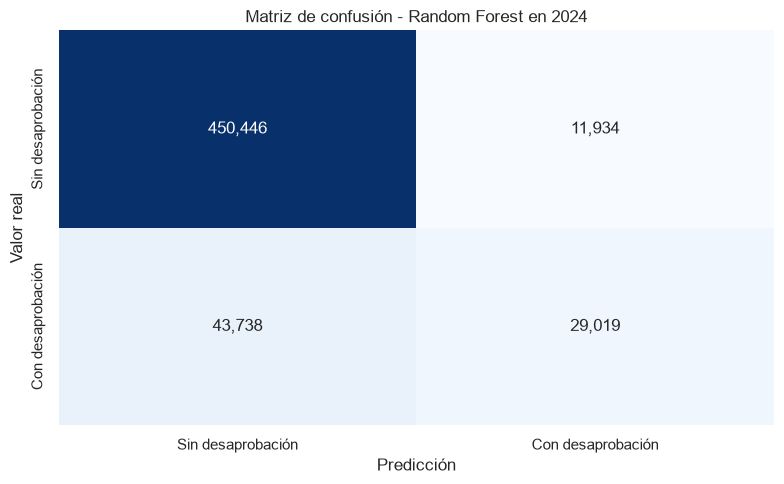

In [51]:
matriz_clas_final = confusion_matrix(y_clas_2024_final, pred_clas_final_2024)
sns.heatmap(
    matriz_clas_final, annot=True, fmt=",d", cmap="Blues", cbar=False,
    xticklabels=["Sin desaprobación", "Con desaprobación"],
    yticklabels=["Sin desaprobación", "Con desaprobación"]
)
plt.title("Matriz de confusión - Random Forest en 2024")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

La matriz permite observar por separado los aciertos y errores de cada clase. Debido al desbalance, se presta especial atención a los falsos negativos y no solo a la cantidad total de aciertos.

### Curva ROC

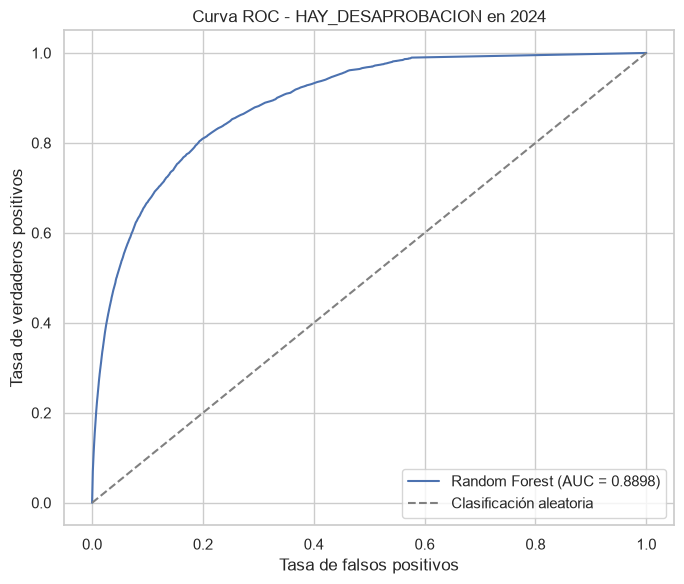

In [52]:
fpr_final, tpr_final, _ = roc_curve(y_clas_2024_final, proba_clas_final_2024)
auc_final_2024 = roc_auc_score(y_clas_2024_final, proba_clas_final_2024)
plt.figure(figsize=(7, 6))
plt.plot(fpr_final, tpr_final, label=f"Random Forest (AUC = {auc_final_2024:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Clasificación aleatoria")
plt.title("Curva ROC - HAY_DESAPROBACION en 2024")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()
plt.tight_layout()
plt.show()

La curva ROC se mantiene claramente por encima de la diagonal y alcanza AUC de 0.8898 en 2024. El modelo separa razonablemente ambas clases, aunque la selección del umbral sigue afectando el Recall.

### Comparación de los cuatro clasificadores

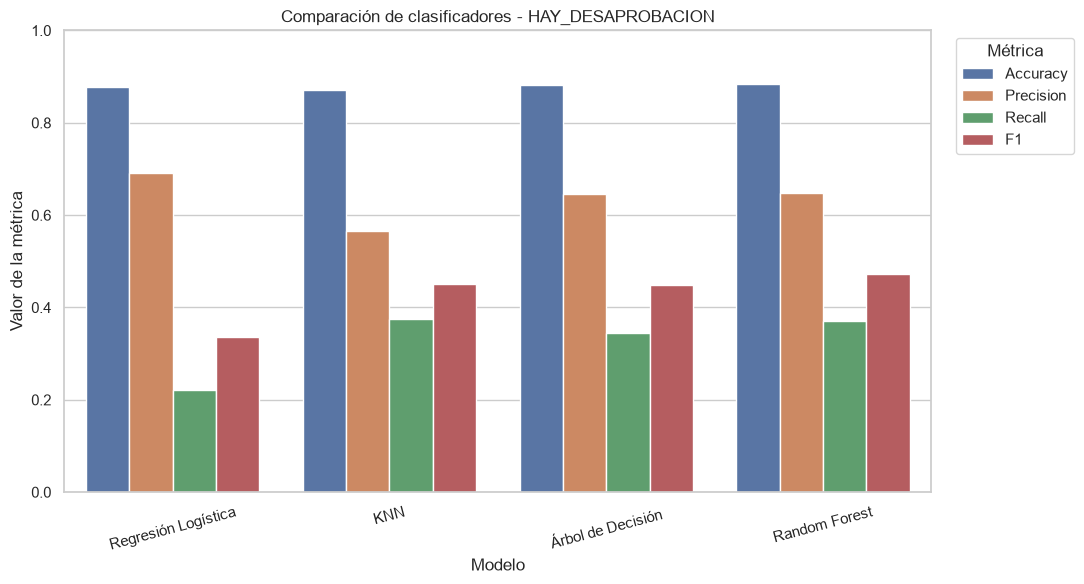

In [53]:
metricas_clas_grafico = resultados_modelos_finales.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Métrica", value_name="Valor"
)
plt.figure(figsize=(11, 6))
sns.barplot(data=metricas_clas_grafico, x="Modelo", y="Valor", hue="Métrica")
plt.title("Comparación de clasificadores - HAY_DESAPROBACION")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Las diferencias más importantes aparecen en Recall y F1, no en Accuracy. Random Forest logra el mejor F1 y ROC-AUC, mientras que KNN obtiene el Recall más alto por un margen pequeño.

## Tarea 2 — Regresión de TASA_DESAPROBACION

In [54]:
y_reg_final_2023 = datos_2023_final["TASA_DESAPROBACION"]
X_reg_final_2023 = datos_2023_final[predictores_contextuales_finales]

X_train_reg_final, X_valid_reg_final, y_train_reg_final, y_valid_reg_final = train_test_split(
    X_reg_final_2023, y_reg_final_2023,
    test_size=0.20, random_state=42
)

pipeline_regresion_final = Pipeline(steps=[
    ("preprocesamiento", crear_preprocesamiento_para(predictores_contextuales_finales)),
    ("modelo", LinearRegression())
])
pipeline_regresion_final.fit(X_train_reg_final, y_train_reg_final)

pred_reg_final_2023 = pipeline_regresion_final.predict(X_valid_reg_final)
X_reg_final_2024 = datos_2024_final[predictores_contextuales_finales]
y_reg_final_2024 = datos_2024_final["TASA_DESAPROBACION"]
pred_reg_final_2024 = pipeline_regresion_final.predict(X_reg_final_2024)

media_reg_final = y_train_reg_final.mean()
baseline_reg_2023 = np.repeat(media_reg_final, len(y_valid_reg_final))
baseline_reg_2024 = np.repeat(media_reg_final, len(y_reg_final_2024))

filas_reg_final = []
for conjunto, y_real, pred_modelo, pred_base in [
    ("Validación 2023", y_valid_reg_final, pred_reg_final_2023, baseline_reg_2023),
    ("Evaluación 2024", y_reg_final_2024, pred_reg_final_2024, baseline_reg_2024)
]:
    for modelo, pred in [("Regresión Lineal", pred_modelo), ("Baseline media", pred_base)]:
        filas_reg_final.append({
            "Conjunto": conjunto,
            "Modelo": modelo,
            "MAE": mean_absolute_error(y_real, pred),
            "RMSE": np.sqrt(mean_squared_error(y_real, pred)),
            "R²": r2_score(y_real, pred)
        })

resultados_regresion_final = pd.DataFrame(filas_reg_final).round(4)
display(resultados_regresion_final)

,Conjunto,Modelo,MAE,RMSE,R²
0,Validación 2023,Regresión Lineal,6.0723,13.5676,0.0705
1,Validación 2023,Baseline media,6.1562,14.0728,-0.0000
2,Evaluación 2024,Regresión Lineal,5.8704,13.3167,0.0854
3,Evaluación 2024,Baseline media,6.0293,13.9254,-0.0001


La Regresión Lineal supera al baseline en ambos periodos: en 2024 obtiene MAE de 5.8704, RMSE de 13.3167 y R² de 0.0854. La mejora existe, pero el R² bajo indica que los predictores contextuales explican solo una parte pequeña de la variación de la tasa.

### Valores reales y predichos

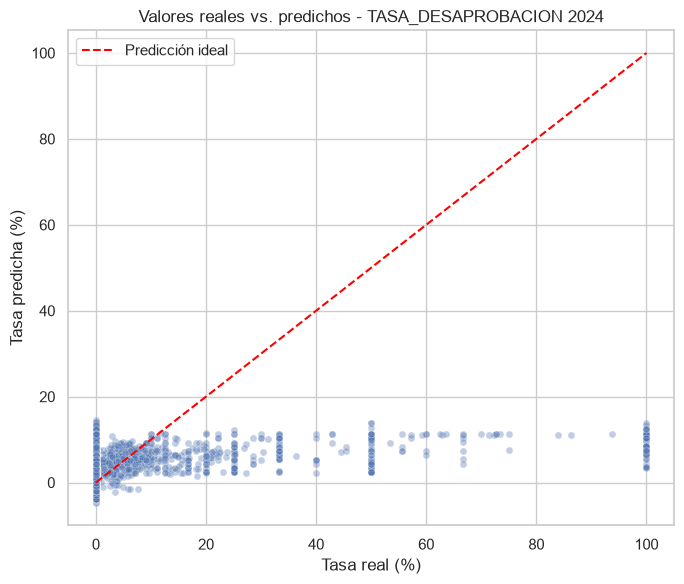

In [55]:
indices_reg_grafico = pd.Series(y_reg_final_2024.index).sample(
    n=min(5_000, len(y_reg_final_2024)), random_state=42
)
reales_reg_grafico = y_reg_final_2024.loc[indices_reg_grafico]
pred_reg_serie = pd.Series(pred_reg_final_2024, index=y_reg_final_2024.index)
predichos_reg_grafico = pred_reg_serie.loc[indices_reg_grafico]

plt.figure(figsize=(7, 6))
sns.scatterplot(x=reales_reg_grafico, y=predichos_reg_grafico, alpha=0.35, s=25)
plt.plot([0, 100], [0, 100], "--", color="red", label="Predicción ideal")
plt.title("Valores reales vs. predichos - TASA_DESAPROBACION 2024")
plt.xlabel("Tasa real (%)")
plt.ylabel("Tasa predicha (%)")
plt.legend()
plt.tight_layout()
plt.show()

Los valores predichos siguen parcialmente la dirección de los valores reales, pero presentan una dispersión amplia y se concentran en un rango reducido. El gráfico confirma que la Regresión Lineal tiene capacidad limitada para representar tasas extremas.

# 19. Resultados finales

In [56]:
fila_rf_validacion = resultados_modelos_finales.loc[
    resultados_modelos_finales["Modelo"] == "Random Forest"
].iloc[0]

tabla_final_clasificacion = pd.DataFrame([
    {
        "Conjunto": "Validación 2023",
        "Modelo": "Random Forest",
        "Accuracy": fila_rf_validacion["Accuracy"],
        "Precision": fila_rf_validacion["Precision"],
        "Recall": fila_rf_validacion["Recall"],
        "F1": fila_rf_validacion["F1"],
        "ROC-AUC": fila_rf_validacion["ROC-AUC"]
    },
    {"Conjunto": "Evaluación 2024", "Modelo": "Random Forest", **metricas_clas_2024_final}
]).round(4)

tabla_final_regresion = resultados_regresion_final[
    resultados_regresion_final["Modelo"] == "Regresión Lineal"
].reset_index(drop=True)

display(tabla_final_clasificacion)
display(tabla_final_regresion)

,Conjunto,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Validación 2023,Random Forest,0.8835,0.6476,0.3709,0.4717,0.8586
1,Evaluación 2024,Random Forest,0.8960,0.7086,0.3988,0.5104,0.8898


,Conjunto,Modelo,MAE,RMSE,R²
0,Validación 2023,Regresión Lineal,6.0723,13.5676,0.0705
1,Evaluación 2024,Regresión Lineal,5.8704,13.3167,0.0854


# 20. Conclusiones técnicas finales

1. Los objetivos definitivos son `HAY_DESAPROBACION` para clasificación y `TASA_DESAPROBACION` para regresión.
2. Se utilizaron `Edad`, `TotalEstudiantes`, `Discapacidad`, `Venezolanos`, `Extranjeros`, `gestion` y `dsc_nivel`; se excluyeron todos los estados académicos que permiten reconstruir los objetivos.
3. `TotalEstudiantes` se conservó porque por sí solo obtuvo F1 de 0.1793 y no determina la desaprobación, aunque influye en la probabilidad de que exista al menos un caso.
4. Random Forest fue el clasificador seleccionado por su mejor equilibrio de F1 y ROC-AUC en la comparación con Regresión Logística, KNN y Árbol de Decisión.
5. En 2024, Random Forest obtuvo Accuracy 0.8960, Precision 0.7086, Recall 0.3988, F1 0.5104 y ROC-AUC 0.8898.
6. La Regresión Lineal obtuvo en 2024 MAE 5.8704, RMSE 13.3167 y R² 0.0854, superando al baseline en MAE y RMSE.
7. Las principales limitaciones son el desbalance de `HAY_DESAPROBACION`, el Recall moderado, la concentración de `TASA_DESAPROBACION` en cero, el R² bajo y la presencia de predicciones negativas en la regresión provisional.
8. Los modelos identifican patrones asociados con desaprobación en registros educativos agregados y evalúan su comportamiento en un periodo posterior; no predicen resultados de estudiantes individuales.